In [1]:
# =========================
# Standard library
# =========================
import os
import sys
import json
import math
import time
import warnings
from pathlib import Path

# =========================
# Data handling
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display

# =========================
# Scikit-learn: preprocessing / splitting
# =========================
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)

# =========================
# Scikit-learn: models
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

# =========================
# Gradient boosting libraries
# =========================
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# =========================
# Metrics
# =========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
    log_loss,
    brier_score_loss
)

# =========================
# Class imbalance
# =========================
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# =========================
# Hyperparameter tuning
# =========================
import optuna
from optuna.integration import OptunaSearchCV

# =========================
# Calibration
# =========================
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# =========================
# Model interpretation
# =========================
import shap
from sklearn.inspection import (
    permutation_importance,
    PartialDependenceDisplay
)

# =========================
# Statistics / diagnostics
# =========================
from scipy import stats
from scipy.stats import (
    ks_2samp,
    chi2_contingency,
    ttest_ind,
    mannwhitneyu,
    shapiro
)

# =========================
# Saving artifacts
# =========================
import joblib
import pickle

# =========================
# API / deployment
# =========================
from fastapi import FastAPI
from pydantic import BaseModel
import uvicorn

from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

import kagglehub

C:\Users\youpi\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def eda(path = None, df =  None):
    if path is not None:
        df = pd.read_csv(path)
    elif df is not None:
        pass
    else:
        raise ValueError("Either path or df must be provided.")

    basic_data_quality_checks(df)
    a_bit_more_comprehensive_quality_checks(df)
    basic_data_visualization(df)
    return df

In [3]:
def basic_data_visualization(df):
    # Display first few rows
    print("First 5 rows:")
    display(df.head())
    
    # Display summary statistics
    print("\nSummary statistics:")
    summary_stats = df.describe()
    display(summary_stats.style.format("{:g}"))
    
    # Display data types and missing values
    print("\nData types and missing values:")
    display(df.info())
    
    # Display target variable distribution
    if 'Exited' in df.columns:
        print("\nTarget variable distribution:")
        display(df['Exited'].value_counts(normalize=True))

In [4]:
def basic_data_quality_checks(df, high_cardinality_threshold = 15, top_n_categories = 15):
    numerical_cols = df.select_dtypes(include=['number']).columns
    categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns

    # Check for duplicates
    print("Data quality overview:")
    print(f"Duplicate rows: {df.duplicated().sum()}")

    # Check for missing values v 2.0
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    print("\nMissing values per column:")
    if missing.empty:
        print("No missing values found.")
    else:
        missing_table = pd.DataFrame({
            'missing_count': missing,
            'missing_pct': (missing / len(df) * 100).round(2)
        })
        display(missing_table.style.format({'missing_pct': '{:.2f}%'}))

    # Check for negative values in numerical columns
    negative_cols = [col for col in numerical_cols if (df[col] < 0).any()]
    print("\nNegative value check:")
    if negative_cols:
        for col in negative_cols:
            print(f"Warning: Column '{col}' contains negative values.")
    else:
        print("No negative values found in numerical columns.")

    # Visual summary for categorical features
    if len(categorical_cols) > 0:
        low_cardinality_cols = [col for col in categorical_cols if df[col].nunique(dropna=False) <= high_cardinality_threshold]
        high_cardinality_cols = [col for col in categorical_cols if df[col].nunique(dropna=False) > high_cardinality_threshold]

        if low_cardinality_cols:
            print("\nCategorical distributions:")
            n_cols = 2
            n_rows = math.ceil(len(low_cardinality_cols) / n_cols)
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
            axes = np.array(axes).reshape(-1)

            for ax, col in zip(axes, low_cardinality_cols):
                counts = df[col].fillna('Missing').value_counts()
                sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, hue=counts.index.astype(str), palette='Blues_d', legend=False)
                ax.set_title(col)
                ax.set_xlabel('')
                ax.set_ylabel('Count')
                ax.tick_params(axis='x', rotation=45)

            for ax in axes[len(low_cardinality_cols):]:
                ax.set_visible(False)

            plt.tight_layout()
            plt.show()

        if high_cardinality_cols:
            print(f"\nHigh-cardinality categorical columns (top {top_n_categories} values):")
            n_cols = 1
            n_rows = len(high_cardinality_cols)
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
            axes = np.atleast_1d(axes)

            for ax, col in zip(axes, high_cardinality_cols):
                counts = df[col].fillna('Missing').value_counts().head(top_n_categories)
                sns.barplot(x=counts.values, y=counts.index.astype(str), ax=ax, hue=counts.index.astype(str), palette='crest', legend=False)
                ax.set_title(f"{col} - descending frequency")
                ax.set_xlabel('Count')
                ax.set_ylabel('')

            plt.tight_layout()
            plt.show()

    # Visual summary for numerical features
    if len(numerical_cols) > 0:
        print("\nNumerical distributions:")
        n_cols = 2
        n_rows = math.ceil(len(numerical_cols) / n_cols)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
        axes = np.array(axes).reshape(-1)

        for ax, col in zip(axes, numerical_cols):
            sns.histplot(df[col].dropna(), bins=30, kde=True, ax=ax, color='steelblue')
            ax.axvline(df[col].mean(), color='crimson', linestyle='--', linewidth=1, label='Mean')
            ax.axvline(df[col].median(), color='darkgreen', linestyle=':', linewidth=1.5, label='Median')
            ax.set_title(col)
            ax.set_xlabel('')
            ax.legend()

        for ax in axes[len(numerical_cols):]:
            ax.set_visible(False)

        plt.tight_layout()
        plt.show()

In [5]:
def _default_range_rules():
    return {
        "CreditScore": {"min": 300, "max": 850},
        "Age": {"min": 18, "max": 100},
        "Tenure": {"min": 0, "max": 10},
        "Balance": {"min": 0},
        "NumOfProducts": {"min": 1, "max": 4},
        "HasCrCard": {"allowed_values": {0, 1}},
        "IsActiveMember": {"allowed_values": {0, 1}},
        "Exited": {"allowed_values": {0, 1}},
        "EstimatedSalary": {"min": 0},
    }


def a_bit_more_comprehensive_quality_checks(
    df,
    invalid_value_rules=None,
    high_cardinality_expected=("Surname",),
    near_constant_threshold=0.99,
    high_cardinality_threshold=15,
):
    print("\nA bit more comprehensive quality checks:")

    invalid_value_rules = invalid_value_rules or _default_range_rules()

    constant_cols = []
    near_constant_rows = []
    for col in df.columns:
        value_counts = df[col].value_counts(dropna=False)
        if value_counts.empty:
            constant_cols.append(col)
            continue

        top_share = value_counts.iloc[0] / len(df)
        nunique = df[col].nunique(dropna=False)

        if nunique <= 1:
            constant_cols.append(col)
        elif top_share >= near_constant_threshold:
            near_constant_rows.append({
                "column": col,
                "top_value": value_counts.index[0],
                "top_value_pct": round(top_share * 100, 2),
                "unique_values": nunique,
            })

    print("\nConstant columns:")
    if constant_cols:
        print(", ".join(constant_cols))
    else:
        print("No constant columns found.")

    print(f"\nNear-constant columns (top value >= {near_constant_threshold:.0%}):")
    if near_constant_rows:
        near_constant_df = pd.DataFrame(near_constant_rows).sort_values(
            "top_value_pct",
            ascending=False,
        )
        display(near_constant_df)
    else:
        print("No near-constant columns found.")

    invalid_rows = []
    for col, rule in invalid_value_rules.items():
        if col not in df.columns:
            continue

        series = df[col].dropna()
        if series.empty:
            continue

        invalid_mask = pd.Series(False, index=series.index)
        rule_parts = []

        if "min" in rule:
            invalid_mask |= series < rule["min"]
            rule_parts.append(f">= {rule['min']}")
        if "max" in rule:
            invalid_mask |= series > rule["max"]
            rule_parts.append(f"<= {rule['max']}")
        if "allowed_values" in rule:
            allowed_values = set(rule["allowed_values"])
            invalid_mask |= ~series.isin(allowed_values)
            rule_parts.append(f"in {sorted(allowed_values)}")

        invalid_count = int(invalid_mask.sum())
        if invalid_count > 0:
            invalid_rows.append({
                "column": col,
                "rule": " and ".join(rule_parts),
                "invalid_count": invalid_count,
                "invalid_pct": round(invalid_count / len(df) * 100, 2),
                "sample_invalid_values": series[invalid_mask].head(5).tolist(),
            })

    print("\nInvalid / impossible values:")
    if invalid_rows:
        invalid_df = pd.DataFrame(invalid_rows).sort_values(
            ["invalid_count", "column"],
            ascending=[False, True],
        )
        display(invalid_df)
    else:
        print("No invalid values found using the active rules.")

    categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns
    expected_high_cardinality = set(high_cardinality_expected)
    cardinality_rows = []
    unexpected_high_cardinality = []

    for col in categorical_cols:
        nunique = df[col].nunique(dropna=False)
        cardinality_rows.append({
            "column": col,
            "unique_values": nunique,
            "expected_high_cardinality": col in expected_high_cardinality,
        })
        if col not in expected_high_cardinality and nunique > high_cardinality_threshold:
            unexpected_high_cardinality.append(col)

    print("\nCategorical cardinality check:")
    if cardinality_rows:
        cardinality_df = pd.DataFrame(cardinality_rows).sort_values(
            "unique_values",
            ascending=False,
        )
        display(cardinality_df)
    else:
        print("No categorical columns found.")

    missing_expected = [col for col in expected_high_cardinality if col not in categorical_cols]
    if unexpected_high_cardinality:
        print(
            "Unexpected high-cardinality categorical columns: "
            + ", ".join(unexpected_high_cardinality)
        )
    else:
        print("No unexpected high-cardinality categorical columns found.")

    if missing_expected:
        print(
            "Expected high-cardinality columns not found in categorical data: "
            + ", ".join(missing_expected)
        )

In [6]:
RELATIONSHIP_DEFAULTS = {
    "redundancy_threshold": 0.85,
    "target_strength_threshold": 0.2,
    "vif_threshold": 5.0,
    "condition_number_threshold": 30.0,
    "proxy_threshold": 0.2,
    "identifier_unique_ratio": 0.95,
    "max_categories_for_categorical": 30,
    "sample_size_for_plots": 2000,
}


def _normalized_series(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return series.dropna()
    return series.dropna()



def _is_identifier_like(series, col_name, unique_ratio_threshold=0.95):
    lower_name = col_name.lower()
    
    # Identifiers: typically explicit ID/key columns
    identifier_markers = ("_id", "id_", "key", "uuid", "identifier", "customerid", "accountid", "rownumber")
    
    # Exclude common numeric feature names that should never be marked as identifiers
    # even if they have high uniqueness (like salary, price, amount, balance, score)
    non_identifier_markers = ("salary", "price", "amount", "balance", "score", "value", 
                              "rate", "percentage", "count", "quantity", "revenue", 
                              "cost", "expense", "income", "payment", "transaction")
    
    non_null = series.dropna()
    if non_null.empty:
        return False
    
    # Quick reject: if the column name contains non-identifier keywords, it's not an identifier
    if any(marker in lower_name for marker in non_identifier_markers):
        return False
    
    unique_ratio = non_null.nunique() / len(non_null)
    # Check for identifier-like name with stricter matching (avoid "id" substring matches)
    looks_like_id_name = any(marker in lower_name for marker in identifier_markers)
    # Check if it's a numeric sequence (e.g., 1, 2, 3, ... or auto-incrementing IDs)
    looks_like_sequence = pd.api.types.is_numeric_dtype(series) and non_null.is_monotonic_increasing and non_null.nunique() == len(non_null)
    return looks_like_id_name or (unique_ratio >= unique_ratio_threshold and not pd.api.types.is_numeric_dtype(series)) or looks_like_sequence



def _safe_cramers_v(x, y):
    valid = pd.DataFrame({"x": x, "y": y}).dropna()
    if valid.empty or valid["x"].nunique() < 2 or valid["y"].nunique() < 2:
        return np.nan, np.nan

    contingency = pd.crosstab(valid["x"], valid["y"])
    if contingency.size == 0:
        return np.nan, np.nan

    chi2, p_value, _, _ = chi2_contingency(contingency)
    n = contingency.values.sum()
    if n == 0:
        return np.nan, p_value

    phi2 = chi2 / n
    r, k = contingency.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    r_corr = r - ((r - 1) ** 2) / max(n - 1, 1)
    k_corr = k - ((k - 1) ** 2) / max(n - 1, 1)
    denom = min(k_corr - 1, r_corr - 1)
    if denom <= 0:
        return np.nan, p_value
    return np.sqrt(phi2_corr / denom), p_value



def _safe_correlation_ratio(categories, measurements):
    valid = pd.DataFrame({"category": categories, "value": measurements}).dropna()
    if valid.empty or valid["category"].nunique() < 2:
        return np.nan, np.nan

    groups = [group["value"].values for _, group in valid.groupby("category")]
    if len(groups) < 2 or any(len(group) == 0 for group in groups):
        return np.nan, np.nan

    overall_mean = valid["value"].mean()
    ss_between = sum(len(group) * (group.mean() - overall_mean) ** 2 for group in groups)
    ss_total = ((valid["value"] - overall_mean) ** 2).sum()
    eta = np.sqrt(ss_between / ss_total) if ss_total > 0 else np.nan

    try:
        _, p_value = stats.f_oneway(*groups)
    except Exception:
        p_value = np.nan
    return eta, p_value



def _target_type(series):
    if pd.api.types.is_bool_dtype(series):
        return "binary"
    if pd.api.types.is_datetime64_any_dtype(series):
        return "datetime"

    non_null = series.dropna()
    if non_null.empty:
        return "unknown"

    nunique = non_null.nunique()
    if pd.api.types.is_numeric_dtype(series):
        if nunique <= 2:
            return "binary"
        if nunique <= 10 and set(non_null.unique()).issubset({0, 1}):
            return "binary"
        return "numeric"

    if nunique <= 2:
        return "binary"
    return "categorical"



def _association_value(series_a, type_a, series_b, type_b):
    valid = pd.DataFrame({"a": series_a, "b": series_b}).dropna()
    if valid.empty:
        return {"method": None, "value": np.nan, "p_value": np.nan}

    if type_a == "numeric" and type_b == "numeric":
        if valid["a"].nunique() < 2 or valid["b"].nunique() < 2:
            return {"method": "pearson", "value": np.nan, "p_value": np.nan}
        corr, p_value = stats.pearsonr(valid["a"], valid["b"])
        return {"method": "pearson", "value": abs(corr), "p_value": p_value}

    if type_a == "categorical" and type_b == "categorical":
        value, p_value = _safe_cramers_v(valid["a"], valid["b"])
        return {"method": "cramers_v", "value": value, "p_value": p_value}

    if type_a == "numeric" and type_b == "categorical":
        value, p_value = _safe_correlation_ratio(valid["b"], valid["a"])
        return {"method": "correlation_ratio", "value": value, "p_value": p_value}

    if type_a == "categorical" and type_b == "numeric":
        value, p_value = _safe_correlation_ratio(valid["a"], valid["b"])
        return {"method": "correlation_ratio", "value": value, "p_value": p_value}

    return {"method": None, "value": np.nan, "p_value": np.nan}


In [7]:
def classify_columns(df, target_col=None, exclude_cols=None):
    if target_col is not None and target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in dataframe.")

    exclude_cols = list(exclude_cols or [])
    excluded = [col for col in exclude_cols if col in df.columns and col != target_col]

    numeric_cols = []
    categorical_cols = []
    boolean_cols = []
    datetime_cols = []
    identifier_cols = []

    for col in df.columns:
        if col == target_col or col in excluded:
            continue

        series = df[col]
        if pd.api.types.is_datetime64_any_dtype(series):
            datetime_cols.append(col)
            continue

        if _is_identifier_like(series, col, RELATIONSHIP_DEFAULTS["identifier_unique_ratio"]):
            identifier_cols.append(col)
            continue

        if pd.api.types.is_bool_dtype(series):
            boolean_cols.append(col)
            continue

        non_null = series.dropna()
        nunique = non_null.nunique()

        if pd.api.types.is_numeric_dtype(series):
            if nunique <= 2 and set(non_null.unique()).issubset({0, 1}):
                boolean_cols.append(col)
            else:
                numeric_cols.append(col)
        else:
            if nunique <= RELATIONSHIP_DEFAULTS["max_categories_for_categorical"]:
                categorical_cols.append(col)
            else:
                identifier_cols.append(col)

    target_type = _target_type(df[target_col]) if target_col is not None else None
    return {
        "target_col": target_col,
        "target_type": target_type,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "boolean_cols": boolean_cols,
        "datetime_cols": datetime_cols,
        "identifier_cols": identifier_cols,
        "excluded_cols": excluded,
        "analysis_numeric_cols": numeric_cols + boolean_cols,
        "analysis_categorical_cols": categorical_cols + boolean_cols,
    }


In [8]:
def numeric_numeric_associations(df, numeric_cols):
    numeric_cols = [col for col in numeric_cols if col in df.columns]
    if len(numeric_cols) < 2:
        return {
            "pearson_matrix": pd.DataFrame(),
            "spearman_matrix": pd.DataFrame(),
            "ranked_pairs": pd.DataFrame(),
        }

    numeric_df = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
    pearson_matrix = numeric_df.corr(method="pearson")
    spearman_matrix = numeric_df.corr(method="spearman")

    rows = []
    for i, left in enumerate(numeric_cols):
        for right in numeric_cols[i + 1:]:
            valid = numeric_df[[left, right]].dropna()
            if len(valid) < 3 or valid[left].nunique() < 2 or valid[right].nunique() < 2:
                continue
            pearson_corr, pearson_p = stats.pearsonr(valid[left], valid[right])
            spearman_corr, spearman_p = stats.spearmanr(valid[left], valid[right])
            rows.append({
                "feature_1": left,
                "feature_2": right,
                "pearson": pearson_corr,
                "pearson_abs": abs(pearson_corr),
                "pearson_p_value": pearson_p,
                "spearman": spearman_corr,
                "spearman_abs": abs(spearman_corr),
                "spearman_p_value": spearman_p,
                "n_obs": len(valid),
            })

    ranked_pairs = pd.DataFrame(rows).sort_values(
        ["spearman_abs", "pearson_abs"],
        ascending=False,
    ) if rows else pd.DataFrame()

    return {
        "pearson_matrix": pearson_matrix,
        "spearman_matrix": spearman_matrix,
        "ranked_pairs": ranked_pairs,
    }

In [9]:
def categorical_categorical_associations(df, cat_cols):
    cat_cols = [col for col in cat_cols if col in df.columns]
    if len(cat_cols) < 2:
        return {
            "cramers_v_matrix": pd.DataFrame(),
            "chi_square_p_matrix": pd.DataFrame(),
            "ranked_pairs": pd.DataFrame(),
        }

    cramers_v_matrix = pd.DataFrame(np.eye(len(cat_cols)), index=cat_cols, columns=cat_cols)
    chi_square_p_matrix = pd.DataFrame(np.zeros((len(cat_cols), len(cat_cols))), index=cat_cols, columns=cat_cols)
    rows = []

    for i, left in enumerate(cat_cols):
        for right in cat_cols[i + 1:]:
            value, p_value = _safe_cramers_v(df[left], df[right])
            cramers_v_matrix.loc[left, right] = value
            cramers_v_matrix.loc[right, left] = value
            chi_square_p_matrix.loc[left, right] = p_value
            chi_square_p_matrix.loc[right, left] = p_value
            rows.append({
                "feature_1": left,
                "feature_2": right,
                "cramers_v": value,
                "chi_square_p_value": p_value,
            })

    ranked_pairs = pd.DataFrame(rows).sort_values("cramers_v", ascending=False) if rows else pd.DataFrame()
    return {
        "cramers_v_matrix": cramers_v_matrix,
        "chi_square_p_matrix": chi_square_p_matrix,
        "ranked_pairs": ranked_pairs,
    }

In [10]:
def numeric_categorical_associations(df, numeric_cols, cat_cols):
    numeric_cols = [col for col in numeric_cols if col in df.columns]
    cat_cols = [col for col in cat_cols if col in df.columns]
    rows = []

    for numeric_col in numeric_cols:
        for cat_col in cat_cols:
            eta, p_value = _safe_correlation_ratio(df[cat_col], pd.to_numeric(df[numeric_col], errors="coerce"))
            rows.append({
                "numeric_feature": numeric_col,
                "categorical_feature": cat_col,
                "correlation_ratio": eta,
                "anova_p_value": p_value,
            })

    ranked_pairs = pd.DataFrame(rows).sort_values("correlation_ratio", ascending=False) if rows else pd.DataFrame()
    pivot_matrix = ranked_pairs.pivot(
        index="numeric_feature",
        columns="categorical_feature",
        values="correlation_ratio",
    ) if not ranked_pairs.empty else pd.DataFrame()

    return {
        "association_matrix": pivot_matrix,
        "ranked_pairs": ranked_pairs,
    }

In [11]:
def target_associations(df, target_col, meta, include_mutual_info=True):
    target_series = df[target_col]
    target_type = meta["target_type"]
    rows = []

    for col in meta["numeric_cols"] + meta["boolean_cols"]:
        feature_series = pd.to_numeric(df[col], errors="coerce")
        if target_type == "numeric":
            valid = pd.DataFrame({"x": feature_series, "y": pd.to_numeric(target_series, errors="coerce")}).dropna()
            if len(valid) >= 3 and valid["x"].nunique() > 1 and valid["y"].nunique() > 1:
                pearson_corr, pearson_p = stats.pearsonr(valid["x"], valid["y"])
                spearman_corr, spearman_p = stats.spearmanr(valid["x"], valid["y"])
                rows.append({
                    "feature": col,
                    "feature_type": "numeric",
                    "method": "pearson_spearman",
                    "association_value": max(abs(pearson_corr), abs(spearman_corr)),
                    "secondary_value": spearman_corr,
                    "p_value": min(pearson_p, spearman_p),
                })
        else:
            assoc = _association_value(feature_series, "numeric", target_series, "categorical")
            rows.append({
                "feature": col,
                "feature_type": "numeric",
                "method": assoc["method"],
                "association_value": assoc["value"],
                "secondary_value": np.nan,
                "p_value": assoc["p_value"],
            })

    for col in meta["categorical_cols"]:
        feature_series = df[col]
        assoc = _association_value(feature_series, "categorical", target_series, target_type if target_type != "binary" else "categorical")
        rows.append({
            "feature": col,
            "feature_type": "categorical",
            "method": assoc["method"],
            "association_value": assoc["value"],
            "secondary_value": np.nan,
            "p_value": assoc["p_value"],
        })

    associations = pd.DataFrame(rows)

    if include_mutual_info and not associations.empty:
        mi_rows = []
        for col in associations["feature"]:
            valid = df[[col, target_col]].dropna().copy()
            if valid.empty:
                mi_rows.append(np.nan)
                continue

            feature = valid[[col]].copy()
            discrete = False
            if col in meta["categorical_cols"] or col in meta["boolean_cols"]:
                feature[col] = feature[col].astype(str).astype("category").cat.codes
                discrete = True
            else:
                feature[col] = pd.to_numeric(feature[col], errors="coerce")

            y = valid[target_col]
            try:
                if target_type == "numeric":
                    y = pd.to_numeric(y, errors="coerce")
                    mi_value = mutual_info_regression(feature, y, discrete_features=[discrete], random_state=42)[0]
                else:
                    y = y.astype(str).astype("category").cat.codes
                    mi_value = mutual_info_classif(feature, y, discrete_features=[discrete], random_state=42)[0]
            except Exception:
                mi_value = np.nan
            mi_rows.append(mi_value)
        associations["mutual_information"] = mi_rows

    associations = associations.sort_values("association_value", ascending=False, na_position="last")
    return associations

In [12]:
def multicollinearity_checks(df, numeric_cols):
    numeric_cols = [col for col in numeric_cols if col in df.columns]
    if len(numeric_cols) < 2:
        return {
            "vif_table": pd.DataFrame(),
            "condition_number": np.nan,
            "eigenvalues": pd.DataFrame(),
            "high_correlation_pairs": pd.DataFrame(),
            "red_flags": [],
        }

    X = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
    X = X.loc[:, X.nunique(dropna=True) > 1]
    if X.shape[1] < 2:
        return {
            "vif_table": pd.DataFrame(),
            "condition_number": np.nan,
            "eigenvalues": pd.DataFrame(),
            "high_correlation_pairs": pd.DataFrame(),
            "red_flags": ["Not enough non-constant numeric predictors for multicollinearity diagnostics."],
        }

    X = X.fillna(X.median())
    X_scaled = (X - X.mean()) / X.std(ddof=0).replace(0, np.nan)
    X_scaled = X_scaled.fillna(0.0)

    vif_rows = []
    for col in X_scaled.columns:
        y = X_scaled[col].values
        X_other = X_scaled.drop(columns=[col]).values
        X_design = np.column_stack([np.ones(len(X_other)), X_other])
        beta, _, _, _ = np.linalg.lstsq(X_design, y, rcond=None)
        y_hat = X_design @ beta
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        vif = np.inf if pd.notna(r_squared) and r_squared >= 0.999 else 1 / max(1 - r_squared, 1e-9)
        vif_rows.append({"feature": col, "vif": vif, "r_squared_on_others": r_squared})

    vif_table = pd.DataFrame(vif_rows).sort_values("vif", ascending=False)
    corr_matrix = X_scaled.corr()
    eigenvalues = np.linalg.eigvalsh(corr_matrix.values)
    singular_values = np.linalg.svd(X_scaled.values, compute_uv=False)
    condition_number = float(np.max(singular_values) / max(np.min(singular_values), 1e-12))

    high_corr_rows = []
    for i, left in enumerate(corr_matrix.columns):
        for right in corr_matrix.columns[i + 1:]:
            corr_value = corr_matrix.loc[left, right]
            if abs(corr_value) >= RELATIONSHIP_DEFAULTS["redundancy_threshold"]:
                high_corr_rows.append({
                    "feature_1": left,
                    "feature_2": right,
                    "correlation": corr_value,
                    "correlation_abs": abs(corr_value),
                })

    high_correlation_pairs = pd.DataFrame(high_corr_rows).sort_values("correlation_abs", ascending=False) if high_corr_rows else pd.DataFrame()
    eigen_table = pd.DataFrame({
        "eigenvalue": np.sort(eigenvalues),
        "near_zero": np.sort(eigenvalues) < 0.05,
    })

    red_flags = []
    if not vif_table.empty and (vif_table["vif"] >= RELATIONSHIP_DEFAULTS["vif_threshold"]).any():
        flagged = vif_table.loc[vif_table["vif"] >= RELATIONSHIP_DEFAULTS["vif_threshold"], "feature"].tolist()
        red_flags.append(f"High VIF detected for: {', '.join(flagged)}")
    if condition_number >= RELATIONSHIP_DEFAULTS["condition_number_threshold"]:
        red_flags.append(f"Condition number {condition_number:.2f} exceeds threshold.")
    if eigen_table["near_zero"].any():
        red_flags.append("Near-zero eigenvalues suggest near-linear dependency among numeric predictors.")

    return {
        "vif_table": vif_table,
        "condition_number": condition_number,
        "eigenvalues": eigen_table,
        "high_correlation_pairs": high_correlation_pairs,
        "red_flags": red_flags,
        "correlation_matrix": corr_matrix,
    }

In [13]:
def proxy_risk_checks(df, target_col, sensitive_cols=None, meta=None, target_association_table=None):
    sensitive_cols = [col for col in (sensitive_cols or []) if col in df.columns and col != target_col]
    if not sensitive_cols:
        return pd.DataFrame()

    if meta is None:
        meta = classify_columns(df, target_col)

    if target_association_table is None:
        target_association_table = target_associations(df, target_col, meta)

    target_lookup = target_association_table.set_index("feature")["association_value"].to_dict() if not target_association_table.empty else {}
    feature_types = {}
    for col in meta["numeric_cols"] + meta["boolean_cols"]:
        feature_types[col] = "numeric"
    for col in meta["categorical_cols"]:
        feature_types[col] = "categorical"

    target_type = meta["target_type"] if meta["target_type"] != "binary" else "categorical"
    sensitive_type_lookup = {col: _target_type(df[col]) for col in sensitive_cols}

    rows = []
    for feature, feature_type in feature_types.items():
        if feature in sensitive_cols:
            continue
        for sensitive_col in sensitive_cols:
            sensitive_type = sensitive_type_lookup[sensitive_col]
            sensitive_type = "categorical" if sensitive_type == "binary" else sensitive_type
            assoc = _association_value(df[feature], feature_type, df[sensitive_col], sensitive_type)
            rows.append({
                "feature": feature,
                "sensitive_attribute": sensitive_col,
                "feature_target_association": target_lookup.get(feature, np.nan),
                "feature_sensitive_association": assoc["value"],
                "sensitive_method": assoc["method"],
                "p_value": assoc["p_value"],
            })

    proxy_table = pd.DataFrame(rows)
    if proxy_table.empty:
        return proxy_table

    proxy_table["proxy_risk_score"] = (
        proxy_table["feature_target_association"].fillna(0)
        * proxy_table["feature_sensitive_association"].fillna(0)
    )
    proxy_table["red_flag"] = (
        proxy_table["feature_target_association"].fillna(0) >= RELATIONSHIP_DEFAULTS["target_strength_threshold"]
    ) & (
        proxy_table["feature_sensitive_association"].fillna(0) >= RELATIONSHIP_DEFAULTS["proxy_threshold"]
    )
    return proxy_table.sort_values("proxy_risk_score", ascending=False)

In [14]:
def plot_relationships(df, report, max_plots=3):
    meta = report["meta"]

    num_num = report["numeric_numeric"]
    if not num_num["pearson_matrix"].empty and num_num["pearson_matrix"].shape[0] > 1:
        sns.clustermap(num_num["pearson_matrix"].fillna(0), cmap="coolwarm", center=0, figsize=(10, 8))
        plt.suptitle("Numeric-Numeric Pearson Correlations", y=1.02)
        plt.show()

    cat_cat = report["categorical_categorical"]
    if not cat_cat["cramers_v_matrix"].empty and cat_cat["cramers_v_matrix"].shape[0] > 1:
        plt.figure(figsize=(8, 6))
        sns.heatmap(cat_cat["cramers_v_matrix"], cmap="viridis", annot=False)
        plt.title("Categorical-Categorical Cramer's V")
        plt.tight_layout()
        plt.show()

    multicol = report["multicollinearity"]
    if not multicol["vif_table"].empty:
        top_vif = multicol["vif_table"].head(10)
        plt.figure(figsize=(8, 5))
        sns.barplot(data=top_vif, x="vif", y="feature", palette="rocket")
        plt.axvline(RELATIONSHIP_DEFAULTS["vif_threshold"], color="crimson", linestyle="--")
        plt.title("Top VIF Scores")
        plt.tight_layout()
        plt.show()

    target_assoc = report["target_associations"]
    if not target_assoc.empty:
        top_target = target_assoc.head(10)
        plt.figure(figsize=(8, 5))
        sns.barplot(data=top_target, x="association_value", y="feature", hue="feature_type", dodge=False, palette="Set2")
        plt.axvline(RELATIONSHIP_DEFAULTS["target_strength_threshold"], color="darkgreen", linestyle=":")
        plt.title("Strongest Feature-Target Associations")
        plt.tight_layout()
        plt.show()

    if not num_num["ranked_pairs"].empty:
        sample_n = min(len(df), RELATIONSHIP_DEFAULTS["sample_size_for_plots"])
        plot_df = df.sample(sample_n, random_state=42) if len(df) > sample_n else df.copy()
        for _, row in num_num["ranked_pairs"].head(max_plots).iterrows():
            plt.figure(figsize=(6, 4))
            sns.scatterplot(data=plot_df, x=row["feature_1"], y=row["feature_2"], alpha=0.6)
            plt.title(f"Scatter: {row['feature_1']} vs {row['feature_2']}")
            plt.tight_layout()
            plt.show()

    num_cat = report["numeric_categorical"]
    if not num_cat["ranked_pairs"].empty:
        sample_n = min(len(df), RELATIONSHIP_DEFAULTS["sample_size_for_plots"])
        plot_df = df.sample(sample_n, random_state=42) if len(df) > sample_n else df.copy()
        for _, row in num_cat["ranked_pairs"].head(max_plots).iterrows():
            plt.figure(figsize=(7, 4))
            sns.boxplot(data=plot_df, x=row["categorical_feature"], y=row["numeric_feature"])
            plt.xticks(rotation=45)
            plt.title(f"Boxplot: {row['numeric_feature']} by {row['categorical_feature']}")
            plt.tight_layout()
            plt.show()

In [15]:
def build_correlation_report(
    df,
    target_col,
    exclude_cols=None,
    sensitive_cols=None,
    include_mutual_info=True,
    include_proxy_risk=True,
    plot=True,
    thresholds=None,
):
    active_thresholds = {**RELATIONSHIP_DEFAULTS, **(thresholds or {})}
    RELATIONSHIP_DEFAULTS.update(active_thresholds)

    meta = classify_columns(df, target_col, exclude_cols=exclude_cols)

    numeric_numeric = numeric_numeric_associations(df, meta["analysis_numeric_cols"])
    categorical_categorical = categorical_categorical_associations(df, meta["analysis_categorical_cols"])
    numeric_categorical = numeric_categorical_associations(
        df,
        meta["analysis_numeric_cols"],
        meta["categorical_cols"],
    )
    target_assoc = target_associations(df, target_col, meta, include_mutual_info=include_mutual_info)
    multicol = multicollinearity_checks(df, meta["analysis_numeric_cols"])
    proxy_table = proxy_risk_checks(
        df,
        target_col,
        sensitive_cols=sensitive_cols,
        meta=meta,
        target_association_table=target_assoc,
    ) if include_proxy_risk else pd.DataFrame()

    redundancy_rows = []
    if not numeric_numeric["ranked_pairs"].empty:
        flagged = numeric_numeric["ranked_pairs"].loc[
            numeric_numeric["ranked_pairs"]["spearman_abs"] >= active_thresholds["redundancy_threshold"]
        ].copy()
        if not flagged.empty:
            flagged["relationship_type"] = "numeric_numeric"
            flagged["strength"] = flagged["spearman_abs"]
            redundancy_rows.append(flagged[["relationship_type", "feature_1", "feature_2", "strength"]])

    if not categorical_categorical["ranked_pairs"].empty:
        flagged = categorical_categorical["ranked_pairs"].loc[
            categorical_categorical["ranked_pairs"]["cramers_v"] >= active_thresholds["redundancy_threshold"]
        ].copy()
        if not flagged.empty:
            flagged["relationship_type"] = "categorical_categorical"
            flagged["strength"] = flagged["cramers_v"]
            redundancy_rows.append(flagged[["relationship_type", "feature_1", "feature_2", "strength"]])

    if not numeric_categorical["ranked_pairs"].empty:
        flagged = numeric_categorical["ranked_pairs"].loc[
            numeric_categorical["ranked_pairs"]["correlation_ratio"] >= active_thresholds["redundancy_threshold"]
        ].copy()
        if not flagged.empty:
            flagged["relationship_type"] = "numeric_categorical"
            flagged = flagged.rename(
                columns={
                    "numeric_feature": "feature_1",
                    "categorical_feature": "feature_2",
                    "correlation_ratio": "strength",
                }
            )
            redundancy_rows.append(flagged[["relationship_type", "feature_1", "feature_2", "strength"]])

    redundancy_table = pd.concat(redundancy_rows, ignore_index=True) if redundancy_rows else pd.DataFrame(
        columns=["relationship_type", "feature_1", "feature_2", "strength"]
    )

    recommendations = []
    if not redundancy_table.empty:
        for _, row in redundancy_table.head(10).iterrows():
            recommendations.append(
                f"Inspect {row['feature_1']} and {row['feature_2']} for redundancy; consider dropping, combining, or regularizing one of them."
            )
    for flag in multicol["red_flags"]:
        recommendations.append(
            flag + " Consider dropping one of the involved predictors, combining them, or using stronger regularization."
        )
    if not target_assoc.empty:
        weak_features = target_assoc.loc[
            target_assoc["association_value"].fillna(0) < 0.05,
            "feature",
        ].head(5).tolist()
        if weak_features:
            recommendations.append(
                "These features look weakly related to the target and may deserve manual review before encoding effort: "
                + ", ".join(weak_features)
            )
        strong_cats = target_assoc.loc[
            (target_assoc["feature_type"] == "categorical")
            & (target_assoc["association_value"].fillna(0) >= active_thresholds["target_strength_threshold"]),
            "feature",
        ].tolist()
        if strong_cats:
            recommendations.append(
                "Strong categorical predictors may benefit from careful encoding choices such as target encoding, regularized one-hot encoding, or frequency encoding: "
                + ", ".join(strong_cats[:5])
            )
    if include_proxy_risk and not proxy_table.empty and proxy_table["red_flag"].any():
        risky = proxy_table.loc[proxy_table["red_flag"], ["feature", "sensitive_attribute"]].head(10)
        for _, row in risky.iterrows():
            recommendations.append(
                f"Proxy-risk review: {row['feature']} is strongly associated with both the target and sensitive attribute {row['sensitive_attribute']}; inspect for fairness or leakage concerns."
            )

    report = {
        "meta": meta,
        "numeric_numeric": numeric_numeric,
        "categorical_categorical": categorical_categorical,
        "numeric_categorical": numeric_categorical,
        "target_associations": target_assoc,
        "multicollinearity": multicol,
        "proxy_risk": proxy_table,
        "redundancy_table": redundancy_table.sort_values("strength", ascending=False, na_position="last"),
        "recommendations": recommendations,
    }

    if plot:
        plot_relationships(df, report)

    print("Column classification:")
    display(pd.DataFrame({key: pd.Series(value) for key, value in meta.items() if isinstance(value, list)}))

    print("\nStrongest feature-feature relationships:")
    strongest_feature_feature = []
    if not numeric_numeric["ranked_pairs"].empty:
        preview = numeric_numeric["ranked_pairs"].head(10).copy()
        preview = preview[["feature_1", "feature_2", "spearman_abs"]].rename(columns={"spearman_abs": "strength"})
        preview["method"] = "spearman_abs"
        strongest_feature_feature.append(preview)
    if not categorical_categorical["ranked_pairs"].empty:
        preview = categorical_categorical["ranked_pairs"].head(10).copy()
        preview = preview[["feature_1", "feature_2", "cramers_v"]].rename(columns={"cramers_v": "strength"})
        preview["method"] = "cramers_v"
        strongest_feature_feature.append(preview)
    if not numeric_categorical["ranked_pairs"].empty:
        preview = numeric_categorical["ranked_pairs"].head(10).copy()
        preview = preview.rename(columns={
            "numeric_feature": "feature_1",
            "categorical_feature": "feature_2",
            "correlation_ratio": "strength",
        })
        preview = preview[["feature_1", "feature_2", "strength"]]
        preview["method"] = "correlation_ratio"
        strongest_feature_feature.append(preview)
    if strongest_feature_feature:
        display(pd.concat(strongest_feature_feature, ignore_index=True).sort_values("strength", ascending=False))
    else:
        print("No pairwise associations were available.")

    print("\nFeature-target associations:")
    display(target_assoc.head(15))

    print("\nMulticollinearity diagnostics:")
    print(
        f"Condition number: {multicol['condition_number']:.2f}"
        if pd.notna(multicol["condition_number"])
        else "Condition number unavailable."
    )
    if not multicol["vif_table"].empty:
        display(multicol["vif_table"].head(15))
    if multicol["red_flags"]:
        print("Red flags:")
        for flag in multicol["red_flags"]:
            print(f"- {flag}")

    if include_proxy_risk:
        print("\nProxy-risk screening:")
        if proxy_table.empty:
            print("No sensitive columns provided or no proxy-risk results available.")
        else:
            display(proxy_table.head(15))

    print("\nRecommendations:")
    if recommendations:
        for recommendation in recommendations[:15]:
            print(f"- {recommendation}")
    else:
        print("No immediate red flags detected. Inspect top-ranked relationships manually for domain plausibility.")

    return report

In [16]:
AUDIT_DEFAULTS = {
    "missing_warn_threshold": 0.2,
    "rare_level_threshold": 0.01,
    "spike_threshold": 0.8,
    "outlier_fraction_warn_threshold": 0.05,
    "anomaly_contamination": 0.05,
    "benford_min_sample": 100,
    "identifier_unique_ratio": RELATIONSHIP_DEFAULTS["identifier_unique_ratio"],
    "plot_sample_size": RELATIONSHIP_DEFAULTS["sample_size_for_plots"],
}


def _coerce_numeric(series):
    return pd.to_numeric(series, errors="coerce")


def _robust_z_scores(series):
    clean = _coerce_numeric(series).dropna()
    if clean.empty:
        return pd.Series(dtype=float)
    median = clean.median()
    mad = np.median(np.abs(clean - median))
    if mad == 0:
        return pd.Series(0.0, index=clean.index)
    return 0.6745 * (clean - median) / mad


def _iqr_bounds(series):
    clean = _coerce_numeric(series).dropna()
    if clean.empty:
        return np.nan, np.nan
    q1 = clean.quantile(0.25)
    q3 = clean.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


def _suitable_for_benford(series):
    clean = _coerce_numeric(series)
    clean = clean[np.isfinite(clean)]
    clean = clean[clean != 0].abs()
    clean = clean[clean >= 1]
    if len(clean) < AUDIT_DEFAULTS["benford_min_sample"]:
        return False, "Too few non-zero positive values for a meaningful Benford check."
    order_span = np.log10(clean.max()) - np.log10(clean.min()) if clean.min() > 0 else 0
    if order_span < 1:
        return False, "Values do not span enough orders of magnitude for Benford-style testing."
    if clean.nunique() / len(clean) < 0.1:
        return False, "Too few distinct values; repeated or capped amounts can distort Benford patterns."
    return True, "Suitable for Benford-style screening."


def _extract_first_digits(series, digits=1):
    clean = _coerce_numeric(series)
    clean = clean[np.isfinite(clean)]
    clean = clean[clean != 0].abs()
    clean = clean[clean >= 1]
    leading = clean.astype(str).str.replace(".", "", regex=False).str.lstrip("0")
    leading = leading[leading.str.len() >= digits]
    if digits == 1:
        return leading.str[0].astype(int)
    return leading.str[:2].astype(int)


def _normalized_entropy(series):
    counts = series.fillna("<MISSING>").astype(str).value_counts(normalize=True)
    if len(counts) <= 1:
        return 0.0
    entropy = -(counts * np.log2(counts)).sum()
    return float(entropy / np.log2(len(counts)))


In [17]:
def run_core_quality_checks(df, meta, invalid_value_rules=None):
    invalid_value_rules = invalid_value_rules or _default_range_rules()
    duplicate_rows = int(df.duplicated().sum())
    summary_rows = []

    for col in meta["numeric_cols"] + meta["categorical_cols"] + meta["boolean_cols"] + meta["datetime_cols"]:
        series = df[col]
        missing_pct = float(series.isna().mean())
        nunique = int(series.nunique(dropna=True))
        warnings_list = []
        invalid_count = 0
        coercion_issue_pct = np.nan

        if missing_pct >= AUDIT_DEFAULTS["missing_warn_threshold"]:
            warnings_list.append("high_missingness")
        if nunique <= 1:
            warnings_list.append("constant")

        if col in meta["categorical_cols"]:
            coerced_numeric = pd.to_numeric(series, errors="coerce")
            if series.notna().sum() > 0:
                coercion_issue_pct = float(coerced_numeric.notna().mean())
                if 0.2 <= coercion_issue_pct <= 0.8:
                    warnings_list.append("mixed_type_pattern")

        if col in invalid_value_rules:
            rule = invalid_value_rules[col]
            clean = series.dropna()
            invalid_mask = pd.Series(False, index=clean.index)
            if "min" in rule:
                invalid_mask |= pd.to_numeric(clean, errors="coerce") < rule["min"]
            if "max" in rule:
                invalid_mask |= pd.to_numeric(clean, errors="coerce") > rule["max"]
            if "allowed_values" in rule:
                invalid_mask |= ~clean.isin(rule["allowed_values"])
            invalid_count = int(invalid_mask.fillna(False).sum())
            if invalid_count > 0:
                warnings_list.append("invalid_values")

        summary_rows.append({
            "column": col,
            "dtype": str(series.dtype),
            "group": (
                "numeric" if col in meta["numeric_cols"] else
                "categorical" if col in meta["categorical_cols"] else
                "boolean" if col in meta["boolean_cols"] else
                "datetime"
            ),
            "missing_pct": round(missing_pct, 4),
            "nunique": nunique,
            "invalid_count": invalid_count,
            "coercion_issue_pct": coercion_issue_pct,
            "warnings": warnings_list,
            "warning_count": len(warnings_list),
            "duplicate_row_count": duplicate_rows,
        })

    summary = pd.DataFrame(summary_rows).sort_values(["warning_count", "missing_pct"], ascending=False)
    return {
        "column_summary": summary,
        "duplicate_row_count": duplicate_rows,
    }


In [18]:
def run_univariate_outlier_checks(df, numeric_cols):
    rows = []
    row_flags = pd.DataFrame(index=df.index)

    for col in [c for c in numeric_cols if c in df.columns]:
        clean = _coerce_numeric(df[col])
        valid = clean.dropna()
        if len(valid) < 5 or valid.nunique() < 2:
            continue

        lower, upper = _iqr_bounds(valid)
        iqr_mask = (clean < lower) | (clean > upper)

        std = valid.std(ddof=0)
        if std > 0:
            z_scores = (clean - valid.mean()) / std
            z_mask = z_scores.abs() > 3
        else:
            z_mask = pd.Series(False, index=clean.index)

        robust_z = _robust_z_scores(clean)
        mad_mask = robust_z.reindex(clean.index).abs() > 3.5

        combined = pd.DataFrame({
            "iqr": iqr_mask.fillna(False),
            "zscore": z_mask.fillna(False),
            "mad": mad_mask.fillna(False),
        })
        row_flags[f"{col}__outlier_votes"] = combined.sum(axis=1)
        rows.append({
            "column": col,
            "iqr_outlier_pct": round(combined["iqr"].mean(), 4),
            "zscore_outlier_pct": round(combined["zscore"].mean(), 4),
            "mad_outlier_pct": round(combined["mad"].mean(), 4),
            "max_outlier_pct": round(combined.mean().max(), 4),
        })

    summary = pd.DataFrame(rows).sort_values("max_outlier_pct", ascending=False) if rows else pd.DataFrame()
    return {
        "column_summary": summary,
        "row_flags": row_flags,
    }


In [19]:
def run_multivariate_anomaly_checks(df, numeric_cols, contamination=None, include_pca=True):
    numeric_cols = [col for col in numeric_cols if col in df.columns]
    if len(numeric_cols) < 2:
        return {
            "row_summary": pd.DataFrame(),
            "model_summary": pd.DataFrame(),
            "pca_projection": pd.DataFrame(),
        }

    contamination = contamination or AUDIT_DEFAULTS["anomaly_contamination"]
    X = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
    X = X.loc[:, X.nunique(dropna=True) > 1]
    if X.shape[1] < 2:
        return {
            "row_summary": pd.DataFrame(),
            "model_summary": pd.DataFrame(),
            "pca_projection": pd.DataFrame(),
        }

    X_filled = X.fillna(X.median())
    X_scaled = (X_filled - X_filled.mean()) / X_filled.std(ddof=0).replace(0, np.nan)
    X_scaled = X_scaled.fillna(0.0)

    iso = IsolationForest(contamination=contamination, random_state=42)
    iso.fit(X_scaled)
    iso_score = -iso.score_samples(X_scaled)
    iso_flag = iso.predict(X_scaled) == -1

    lof = LocalOutlierFactor(n_neighbors=min(20, max(5, len(X_scaled) // 10)), contamination=contamination)
    lof_flag = lof.fit_predict(X_scaled) == -1
    lof_score = -lof.negative_outlier_factor_

    row_summary = pd.DataFrame({
        "isolation_forest_score": iso_score,
        "lof_score": lof_score,
        "isolation_forest_flag": iso_flag,
        "lof_flag": lof_flag,
    }, index=df.index)
    row_summary["anomaly_vote_count"] = row_summary[["isolation_forest_flag", "lof_flag"]].sum(axis=1)
    row_summary["combined_anomaly_score"] = (
        pd.Series(iso_score, index=df.index).rank(pct=True)
        + pd.Series(lof_score, index=df.index).rank(pct=True)
    ) / 2
    row_summary = row_summary.sort_values(["anomaly_vote_count", "combined_anomaly_score"], ascending=False)

    pca_projection = pd.DataFrame(index=df.index)
    pca_loadings = pd.DataFrame()
    pca_explained_variance = {}
    pca_component_keys = {}
    colour_keys = {}

    if include_pca:
        n_components = min(2, X_scaled.shape[1])
        pca = PCA(n_components=n_components)
        comps = pca.fit_transform(X_scaled)
        pc_names = [f"PC{i+1}" for i in range(comps.shape[1])]

        pca_projection = pd.DataFrame(comps, columns=pc_names, index=df.index)
        pca_projection["combined_anomaly_score"] = row_summary.loc[pca_projection.index, "combined_anomaly_score"]
        pca_projection["anomaly_vote_count"] = row_summary.loc[pca_projection.index, "anomaly_vote_count"]

        pca_loadings = pd.DataFrame(pca.components_.T, index=X_scaled.columns, columns=pc_names)
        for pc in pc_names:
            sorted_features = pca_loadings[pc].abs().sort_values(ascending=False)
            top_features = sorted_features.head(5).index.tolist()
            pca_component_keys[pc] = [f"{feat} ({pca_loadings.at[feat, pc]:+.3f})" for feat in top_features]
            pca_explained_variance[pc] = float(pca.explained_variance_ratio_[pc_names.index(pc)] * 100)

        colour_keys = {
            "primary": "combined_anomaly_score",
            "secondary": "anomaly_vote_count",
            "description": (
                "Primary colour grading key is the continuous combined anomaly score; "
                "secondary key is the discrete anomaly vote count for categorical colouring."
            ),
        }

    model_summary = pd.DataFrame({
        "metric": ["isolation_forest_flag_rate", "lof_flag_rate"],
        "value": [float(iso_flag.mean()), float(lof_flag.mean())],
    })
    return {
        "row_summary": row_summary,
        "model_summary": model_summary,
        "pca_projection": pca_projection,
        "pca_loadings": pca_loadings,
        "pca_explained_variance": pca_explained_variance,
        "pca_component_keys": pca_component_keys,
        "colour_keys": colour_keys,
    }


In [20]:
def run_distribution_checks(df, numeric_cols):
    rows = []
    for col in [c for c in numeric_cols if c in df.columns]:
        clean = _coerce_numeric(df[col]).dropna()
        if len(clean) < 8 or clean.nunique() < 2:
            continue

        sample = clean.sample(min(len(clean), 5000), random_state=42) if len(clean) > 5000 else clean
        try:
            if len(sample) <= 5000:
                _, normality_p = shapiro(sample)
            else:
                _, normality_p = stats.normaltest(sample)
        except Exception:
            normality_p = np.nan

        rows.append({
            "column": col,
            "skewness": float(clean.skew()),
            "kurtosis": float(clean.kurtosis()),
            "normality_p_value": normality_p,
            "non_normal_warning": bool(pd.notna(normality_p) and normality_p < 0.05),
        })

    return pd.DataFrame(rows).sort_values("normality_p_value", ascending=True, na_position="last") if rows else pd.DataFrame()


In [21]:
def run_benford_checks(df, numeric_cols):
    rows = []
    expected_first = np.log10(1 + 1 / np.arange(1, 10))
    first_two_range = np.arange(10, 100)
    expected_first_two = np.log10(1 + 1 / first_two_range)

    for col in [c for c in numeric_cols if c in df.columns]:
        suitable, note = _suitable_for_benford(df[col])
        result = {
            "column": col,
            "applicable": suitable,
            "note": note,
            "first_digit_mad": np.nan,
            "first_digit_chi_square": np.nan,
            "first_two_digit_mad": np.nan,
            "first_two_digit_chi_square": np.nan,
            "warning": False,
        }
        if not suitable:
            rows.append(result)
            continue

        first_digits = _extract_first_digits(df[col], digits=1)
        observed_first = first_digits.value_counts(normalize=True).reindex(range(1, 10), fill_value=0).values
        chi_first = float(((observed_first - expected_first) ** 2 / expected_first).sum() * len(first_digits))
        mad_first = float(np.mean(np.abs(observed_first - expected_first)))

        first_two_digits = _extract_first_digits(df[col], digits=2)
        observed_first_two = first_two_digits.value_counts(normalize=True).reindex(first_two_range, fill_value=0).values
        chi_first_two = float(((observed_first_two - expected_first_two) ** 2 / expected_first_two).sum() * len(first_two_digits)) if len(first_two_digits) > 0 else np.nan
        mad_first_two = float(np.mean(np.abs(observed_first_two - expected_first_two))) if len(first_two_digits) > 0 else np.nan

        result.update({
            "first_digit_mad": mad_first,
            "first_digit_chi_square": chi_first,
            "first_two_digit_mad": mad_first_two,
            "first_two_digit_chi_square": chi_first_two,
            "warning": bool(mad_first > 0.015 or (pd.notna(mad_first_two) and mad_first_two > 0.0045)),
        })
        rows.append(result)

    return pd.DataFrame(rows).sort_values(["warning", "first_digit_mad"], ascending=[False, False]) if rows else pd.DataFrame()


In [22]:
def run_digit_preference_checks(df, numeric_cols):
    rows = []
    for col in [c for c in numeric_cols if c in df.columns]:
        clean = _coerce_numeric(df[col]).dropna()
        if len(clean) < 20:
            continue

        abs_clean = clean.abs()
        last_digits = (np.floor(abs_clean * 100).astype(int) % 10)
        last_digit_counts = last_digits.value_counts(normalize=True).reindex(range(10), fill_value=0)
        expected = np.repeat(0.1, 10)
        last_digit_mad = float(np.mean(np.abs(last_digit_counts.values - expected)))
        last_digit_chi = float(((last_digit_counts.values - expected) ** 2 / expected).sum() * len(last_digits))
        round_number_rate = float(((abs_clean % 10) == 0).mean())
        repeated_value_share = float(abs_clean.value_counts(normalize=True).iloc[0])

        rows.append({
            "column": col,
            "last_digit_mad": last_digit_mad,
            "last_digit_chi_square": last_digit_chi,
            "round_number_rate": round_number_rate,
            "repeated_value_share": repeated_value_share,
            "warning": bool(last_digit_mad > 0.02 or round_number_rate > 0.25 or repeated_value_share > 0.2),
        })

    return pd.DataFrame(rows).sort_values(["warning", "last_digit_mad", "round_number_rate"], ascending=[False, False, False]) if rows else pd.DataFrame()


In [23]:
def run_categorical_checks(df, categorical_cols):
    summary_rows = []
    row_flags = pd.DataFrame(index=df.index)
    invalid_tokens = {"", "unknown", "n/a", "na", "none", "null", "missing", "?"}

    for col in [c for c in categorical_cols if c in df.columns]:
        series = df[col].fillna("<MISSING>").astype(str).str.strip()
        freqs = series.value_counts(normalize=True)
        rare_levels = freqs[freqs < AUDIT_DEFAULTS["rare_level_threshold"]].index.tolist()
        suspicious_spike = float(freqs.iloc[0]) if not freqs.empty else 0.0
        invalid_label_rate = float(series.str.lower().isin(invalid_tokens).mean())
        entropy = _normalized_entropy(series)

        row_flags[f"{col}__rare_level"] = series.isin(rare_levels)
        row_flags[f"{col}__invalid_label"] = series.str.lower().isin(invalid_tokens)

        summary_rows.append({
            "column": col,
            "n_levels": int(series.nunique()),
            "rare_level_count": len(rare_levels),
            "top_level_share": suspicious_spike,
            "invalid_label_rate": invalid_label_rate,
            "normalized_entropy": entropy,
            "warning": bool(suspicious_spike >= AUDIT_DEFAULTS["spike_threshold"] or invalid_label_rate > 0 or len(rare_levels) > 0),
            "rare_levels_preview": rare_levels[:5],
        })

    summary = pd.DataFrame(summary_rows).sort_values(["warning", "top_level_share"], ascending=[False, False]) if summary_rows else pd.DataFrame()
    return {
        "column_summary": summary,
        "row_flags": row_flags,
    }


In [24]:
def run_rule_checks(df, rules=None):
    rules = rules or []
    if not rules:
        return {
            "summary": pd.DataFrame(),
            "row_flags": pd.DataFrame(index=df.index),
        }

    row_flags = pd.DataFrame(index=df.index)
    rows = []
    for idx, rule in enumerate(rules, start=1):
        rule_name = rule.get("name", f"rule_{idx}")
        if "query" in rule:
            failing_index = df.query(rule["query"]).index
        elif "callable" in rule:
            failing_index = df.index[df.apply(rule["callable"], axis=1)]
        else:
            raise ValueError(f"Rule '{rule_name}' must define either 'query' or 'callable'.")

        row_flags[rule_name] = False
        row_flags.loc[failing_index, rule_name] = True
        rows.append({
            "rule": rule_name,
            "description": rule.get("description", ""),
            "failing_rows": int(len(failing_index)),
            "failing_pct": float(len(failing_index) / len(df)) if len(df) > 0 else 0.0,
        })

    summary = pd.DataFrame(rows).sort_values("failing_rows", ascending=False)
    return {
        "summary": summary,
        "row_flags": row_flags,
    }


In [25]:
def plot_pca_variance_analysis(pca_explained_variance):
    if pca_explained_variance is None:
        print("No PCA explained variance data available for scree plot.")
        return

    if isinstance(pca_explained_variance, pd.Series):
        pca_explained_variance = pca_explained_variance.to_dict()

    if not isinstance(pca_explained_variance, dict) or len(pca_explained_variance) < 2:
        print("PCA requires at least two components to plot explained variance.")
        return

    pc_names = sorted(
        pca_explained_variance.keys(),
        key=lambda x: int(str(x).replace("PC", "").replace("pc", "")) if str(x).lower().startswith("pc") else str(x)
    )
    variances = [float(pca_explained_variance[pc]) for pc in pc_names]
    cumulative_variance = np.cumsum(variances)
    x = np.arange(1, len(pc_names) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(x)))
    ax1.bar(x, variances, color=colors, edgecolor="black")
    ax1.plot(x, variances, color="red", marker="o", linewidth=2, markersize=6)
    ax1.set_xticks(x)
    ax1.set_xticklabels(pc_names, rotation=45, ha="right")
    ax1.set_ylabel("Explained Variance (%)")
    ax1.set_title("Scree Plot: Individual Explained Variance")
    ax1.grid(axis="y", linestyle="--", alpha=0.4)

    ax2.plot(x, cumulative_variance, color="navy", marker="o", linewidth=2)
    ax2.fill_between(x, cumulative_variance, color="navy", alpha=0.12)
    ax2.axhline(80, color="red", linestyle="--", linewidth=1, label="80% threshold")
    ax2.axhline(90, color="orange", linestyle="--", linewidth=1, label="90% threshold")
    ax2.set_xticks(x)
    ax2.set_xticklabels(pc_names, rotation=45, ha="right")
    ax2.set_ylabel("Cumulative Explained Variance (%)")
    ax2.set_title("Cumulative Variance")
    ax2.set_ylim(0, 100)
    ax2.legend(loc="lower right")
    ax2.grid(axis="y", linestyle="--", alpha=0.4)

    fig.suptitle("PCA Variance Analysis", fontsize=14)
    plt.show()


In [26]:
def plot_audit_visualizations(df, report, max_numeric_plots=4, max_categorical_plots=4):
    numeric_cols = report["meta"]["analysis_numeric_cols"]
    categorical_cols = report["meta"]["analysis_categorical_cols"]
    sample_n = min(len(df), AUDIT_DEFAULTS["plot_sample_size"])
    plot_df = df.sample(sample_n, random_state=42) if len(df) > sample_n else df.copy()

    for col in numeric_cols[:max_numeric_plots]:
        plt.figure(figsize=(8, 4))
        sns.histplot(_coerce_numeric(plot_df[col]).dropna(), kde=True, bins=30, color="steelblue")
        plt.title(f"Distribution: {col}")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(6, 4))
        stats.probplot(_coerce_numeric(plot_df[col]).dropna(), dist="norm", plot=plt)
        plt.title(f"Q-Q Plot: {col}")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(6, 3))
        sns.boxplot(x=_coerce_numeric(plot_df[col]), color="darkorange")
        plt.title(f"Outlier Screen: {col}")
        plt.tight_layout()
        plt.show()

    for col in categorical_cols[:max_categorical_plots]:
        plt.figure(figsize=(8, 4))
        counts = plot_df[col].fillna("<MISSING>").astype(str).value_counts().head(15)
        sns.barplot(x=counts.index, y=counts.values, palette="crest")
        plt.xticks(rotation=45, ha="right")
        plt.title(f"Categorical Levels: {col}")
        plt.tight_layout()
        plt.show()

    multivar = report["multivariate_anomalies"]
    if not multivar["pca_projection"].empty and {"PC1", "PC2"}.issubset(multivar["pca_projection"].columns):
        plot_pca_variance_analysis(multivar["pca_explained_variance"])

        if multivar["pca_component_keys"]:
            print("PCA Component Keys (Top Contributing Features):")
            for pc, features in multivar["pca_component_keys"].items():
                print(f"  {pc}: {', '.join(features)}")

        fig, ax = plt.subplots(figsize=(10, 8))

        scatter = ax.scatter(
            multivar["pca_projection"]["PC1"],
            multivar["pca_projection"]["PC2"],
            c=multivar["pca_projection"]["combined_anomaly_score"],
            cmap="magma",
            s=40,
            alpha=0.6,
            edgecolors='k',
            linewidth=0.5
        )

        if not multivar["pca_loadings"].empty:
            pc1_range = multivar["pca_projection"]["PC1"].max() - multivar["pca_projection"]["PC1"].min()
            pc2_range = multivar["pca_projection"]["PC2"].max() - multivar["pca_projection"]["PC2"].min()
            scale_factor = (pc1_range + pc2_range) / 4

            loadings = multivar["pca_loadings"].values
            feature_names = multivar["pca_loadings"].index.tolist()

            for i, feature in enumerate(feature_names):
                pc1_load = loadings[i, 0] * scale_factor
                pc2_load = loadings[i, 1] * scale_factor
                ax.arrow(0, 0, pc1_load, pc2_load,
                         head_width=0.08 * scale_factor,
                         head_length=0.08 * scale_factor,
                         fc='red',
                         ec='red',
                         alpha=0.7,
                         linewidth=1.5,
                         zorder=5)
                ax.text(pc1_load * 1.15,
                        pc2_load * 1.15,
                        feature, fontsize=9, ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.6),
                        zorder=6)

        pc1_var = multivar["pca_explained_variance"].get("PC1", 0)
        pc2_var = multivar["pca_explained_variance"].get("PC2", 0)
        ax.set_xlabel(f"PC1 ({pc1_var:.2f}%)")
        ax.set_ylabel(f"PC2 ({pc2_var:.2f}%)")
        ax.set_title("PCA Biplot with Feature Loadings Colored by Anomaly Score")
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
        ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)

        cbar = plt.colorbar(scatter, ax=ax, label="Anomaly Score")
        plt.tight_layout()
        plt.show()

    if not report["benford_checks"].empty:
        applicable = report["benford_checks"].loc[report["benford_checks"]["applicable"]]
        if not applicable.empty:
            plt.figure(figsize=(8, 4))
            sns.barplot(data=applicable.head(10), x="first_digit_mad", y="column", palette="rocket")
            plt.title("Benford First-Digit MAD")
            plt.tight_layout()
            plt.show()

    if not report["digit_preference_checks"].empty:
        plt.figure(figsize=(8, 4))
        sns.barplot(data=report["digit_preference_checks"].head(10), x="round_number_rate", y="column", palette="flare")
        plt.title("Round-Number Heaping Rate")
        plt.tight_layout()
        plt.show()


In [27]:
def build_summary_report(
    df,
    exclude_cols=None,
    invalid_value_rules=None,
    rules=None,
    plot=True,
    thresholds=None,
):
    active_thresholds = {**AUDIT_DEFAULTS, **(thresholds or {})}
    AUDIT_DEFAULTS.update(active_thresholds)

    meta = classify_columns(df, target_col=None, exclude_cols=exclude_cols)
    core_quality = run_core_quality_checks(df, meta, invalid_value_rules=invalid_value_rules)
    univariate = run_univariate_outlier_checks(df, meta["analysis_numeric_cols"])
    multivariate = run_multivariate_anomaly_checks(df, meta["analysis_numeric_cols"])
    distribution = run_distribution_checks(df, meta["analysis_numeric_cols"])
    benford = run_benford_checks(df, meta["numeric_cols"])
    digit_pref = run_digit_preference_checks(df, meta["numeric_cols"])
    categorical = run_categorical_checks(df, meta["analysis_categorical_cols"])
    rule_checks = run_rule_checks(df, rules=rules)

    column_summary = core_quality["column_summary"].copy()
    if not univariate["column_summary"].empty:
        column_summary = column_summary.merge(univariate["column_summary"], on="column", how="left")
    if not distribution.empty:
        column_summary = column_summary.merge(distribution, on="column", how="left")
    if not benford.empty:
        column_summary = column_summary.merge(benford, on="column", how="left")
    if not digit_pref.empty:
        column_summary = column_summary.merge(digit_pref, on="column", how="left")
    if not categorical["column_summary"].empty:
        column_summary = column_summary.merge(categorical["column_summary"], on="column", how="left")

    column_summary["column_suspicion_score"] = (
        column_summary["warning_count"].fillna(0)
        + 5 * column_summary.get("max_outlier_pct", pd.Series(0, index=column_summary.index)).fillna(0)
        + 2 * column_summary.get("first_digit_mad", pd.Series(0, index=column_summary.index)).fillna(0)
        + 2 * column_summary.get("last_digit_mad", pd.Series(0, index=column_summary.index)).fillna(0)
        + 2 * column_summary.get("top_level_share", pd.Series(0, index=column_summary.index)).fillna(0)
        + column_summary.get("invalid_count", pd.Series(0, index=column_summary.index)).fillna(0) / max(len(df), 1)
    )
    column_summary = column_summary.sort_values("column_suspicion_score", ascending=False)

    row_summary = pd.DataFrame(index=df.index)
    if not univariate["row_flags"].empty:
        row_summary = row_summary.join(univariate["row_flags"], how="left")
    if not categorical["row_flags"].empty:
        row_summary = row_summary.join(categorical["row_flags"], how="left")
    if not rule_checks["row_flags"].empty:
        row_summary = row_summary.join(rule_checks["row_flags"], how="left")
    if not multivariate["row_summary"].empty:
        row_summary = row_summary.join(multivariate["row_summary"], how="left")

    vote_cols = [col for col in row_summary.columns if col.endswith("_flag") or col.endswith("_votes") or "rare_level" in col or "invalid_label" in col]
    row_summary["rule_violation_count"] = rule_checks["row_flags"].sum(axis=1) if not rule_checks["row_flags"].empty else 0
    row_summary["suspicious_signal_count"] = row_summary[vote_cols].fillna(0).sum(axis=1) if vote_cols else 0
    if "combined_anomaly_score" not in row_summary.columns:
        row_summary["combined_anomaly_score"] = 0.0
    row_summary["row_suspicion_score"] = row_summary["suspicious_signal_count"] + row_summary["rule_violation_count"] + row_summary["combined_anomaly_score"].fillna(0)
    row_summary = row_summary.sort_values(["row_suspicion_score", "combined_anomaly_score"], ascending=False)

    recommendations = []
    if core_quality["duplicate_row_count"] > 0:
        recommendations.append(f"Inspect {core_quality['duplicate_row_count']} duplicate rows before modeling or reporting.")
    high_missing = column_summary.loc[column_summary["missing_pct"] >= active_thresholds["missing_warn_threshold"], "column"].tolist()
    if high_missing:
        recommendations.append("High missingness columns may require imputation, exclusion, or business clarification: " + ", ".join(high_missing[:8]))
    benford_flags = benford.loc[benford.get("warning", pd.Series(dtype=bool)).fillna(False), "column"].tolist() if not benford.empty else []
    if benford_flags:
        recommendations.append("Benford deviations are warning signals only, not proof of fraud. Review these columns with domain context: " + ", ".join(benford_flags[:8]))
    digit_flags = digit_pref.loc[digit_pref.get("warning", pd.Series(dtype=bool)).fillna(False), "column"].tolist() if not digit_pref.empty else []
    if digit_flags:
        recommendations.append("Digit preference or heaping is elevated for: " + ", ".join(digit_flags[:8]))
    if not rule_checks["summary"].empty:
        broken = rule_checks["summary"].loc[rule_checks["summary"]["failing_rows"] > 0, "rule"].tolist()
        if broken:
            recommendations.append("Business-rule violations found for: " + ", ".join(broken[:8]))
    if not multivariate["row_summary"].empty:
        flagged_rate = float((multivariate["row_summary"]["anomaly_vote_count"] > 0).mean())
        if flagged_rate > active_thresholds["anomaly_contamination"]:
            recommendations.append(f"Multivariate anomaly models flagged {flagged_rate:.1%} of rows; inspect the top-ranked records manually.")

    report = {
        "meta": meta,
        "core_quality": core_quality,
        "univariate_outliers": univariate,
        "multivariate_anomalies": multivariate,
        "distribution_checks": distribution,
        "benford_checks": benford,
        "digit_preference_checks": digit_pref,
        "categorical_checks": categorical,
        "rule_checks": rule_checks,
        "column_summary": column_summary,
        "row_summary": row_summary,
        "recommendations": recommendations,
    }

    if plot:
        plot_audit_visualizations(df, report)

    print("Column classification:")
    display(pd.DataFrame({key: pd.Series(value) for key, value in meta.items() if isinstance(value, list)}))

    print("\nColumn-level summary:")
    display(column_summary.head(20))

    print("\nMost suspicious rows:")
    display(row_summary.head(20))

    print("\nBenford applicability notes:")
    if benford.empty:
        print("No numeric columns available for Benford-style screening.")
    else:
        display(benford[["column", "applicable", "note", "warning"]].head(20))

    print("\nRecommendations:")
    if recommendations:
        for recommendation in recommendations[:15]:
            print(f"- {recommendation}")
    else:
        print("No immediate red flags detected. Non-normality or Benford deviations alone should not be treated as proof of fabricated data.")

    return report


Original balance count: 10000
Non-zero balance count: 6383
Percentage of non-zero balances: 63.83%


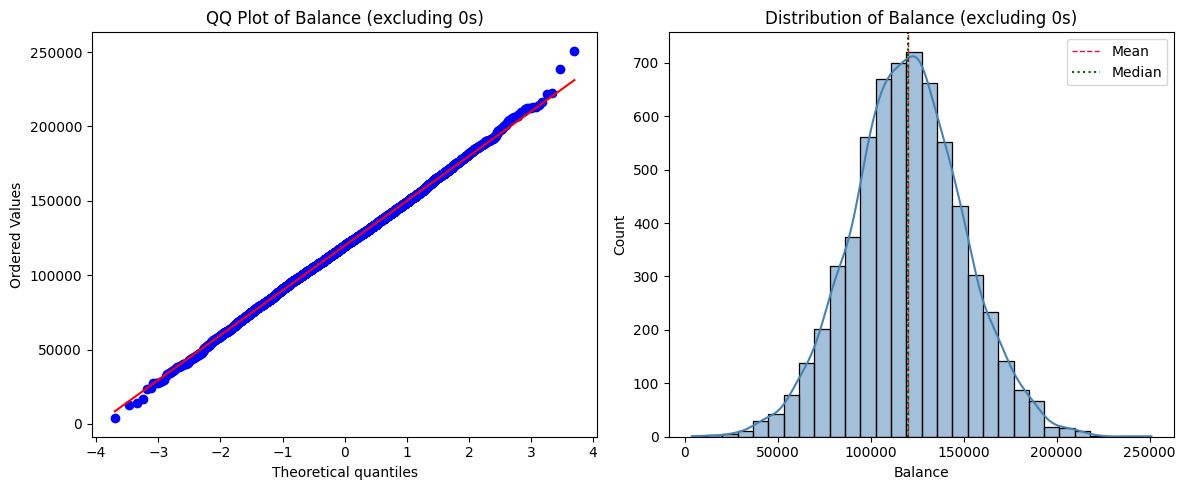

In [ ]:
def check_balance_qq_and_dist(df, balance_col='Balance'):
    """
    Create QQ plot and distribution plot for balance column, excluding zero values.
    """
    import scipy.stats as stats
    
    balance = df[balance_col]
    
    # Filter out 0s
    balance_nonzero = balance[balance > 0]
    
    print(f"Original balance count: {len(balance)}")
    print(f"Non-zero balance count: {len(balance_nonzero)}")
    print(f"Percentage of non-zero balances: {len(balance_nonzero)/len(balance)*100:.2f}%")
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # QQ plot
    stats.probplot(balance_nonzero, dist="norm", plot=ax1)
    ax1.set_title('QQ Plot of Balance (excluding 0s)')
    
    # Distribution plot
    sns.histplot(balance_nonzero, bins=30, kde=True, ax=ax2, color='steelblue')
    ax2.axvline(balance_nonzero.mean(), color='crimson', linestyle='--', linewidth=1, label='Mean')
    ax2.axvline(balance_nonzero.median(), color='darkgreen', linestyle=':', linewidth=1.5, label='Median')
    ax2.set_title('Distribution of Balance (excluding 0s)')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Load data if not already loaded
try:
    df
except NameError:
    import kagglehub
    df = pd.read_csv(os.path.join(kagglehub.dataset_download("shrutimechlearn/churn-modelling"), "Churn_Modelling.csv"))

In [30]:
def compute_balance_benford_mad(df, balance_col="Balance", digits=1):
    """Compute Benford MAD for balance excluding zero values."""
    clean = _coerce_numeric(df[balance_col])
    clean = clean[np.isfinite(clean)]
    clean = clean[clean != 0].abs()
    clean = clean[clean >= 1]

    if len(clean) < AUDIT_DEFAULTS["benford_min_sample"]:
        raise ValueError(
            f"Too few non-zero positive values for a meaningful Benford check: "
            f"found {len(clean)}, need at least {AUDIT_DEFAULTS['benford_min_sample']}"
        )

    if digits == 1:
        expected = np.log10(1 + 1 / np.arange(1, 10))
        observed = _extract_first_digits(clean, digits=1)
        observed = observed.value_counts(normalize=True).reindex(range(1, 10), fill_value=0).values
    elif digits == 2:
        expected = np.log10(1 + 1 / np.arange(10, 100))
        observed = _extract_first_digits(clean, digits=2)
        observed = observed.value_counts(normalize=True).reindex(np.arange(10, 100), fill_value=0).values
    else:
        raise ValueError("digits must be 1 or 2")

    return float(np.mean(np.abs(observed - expected)))


# Example usage
try:
    df
except NameError:
    import kagglehub
    df = pd.read_csv(os.path.join(kagglehub.dataset_download("shrutimechlearn/churn-modelling"), "Churn_Modelling.csv"))

print("Balance Benford MAD (excluding 0s):")
print(" first digit MAD:", compute_balance_benford_mad(df, "Balance", digits=1))
print(" first two digit MAD:", compute_balance_benford_mad(df, "Balance", digits=2))

Balance Benford MAD (excluding 0s):
 first digit MAD: 0.11234525474424717
 first two digit MAD: 0.011840998915983371


In [31]:
def print_balance_round_heaping(df, balance_col="Balance", round_levels=(10, 100, 1000, 10000, 100000), chart_width=40):
    """Print a text-based heaping rate chart for balance, excluding zero values."""
    balances = _coerce_numeric(df[balance_col])
    balances = balances[np.isfinite(balances)]
    balances = balances[balances != 0].abs()
    balances = balances[balances >= 1]

    if balances.empty:
        print(f"No positive non-zero values found in '{balance_col}'.")
        return

    n = len(balances)
    print(f"Round-number heaping rates for '{balance_col}' (excluding zeros):")
    print("Value type          Rate   Count     Chart")
    print("-------------------  ------  -------  ----------------------------------------")

    for base in round_levels:
        mask = balances % base == 0
        count = int(mask.sum())
        rate = count / n
        bar = "█" * int(rate * chart_width)
        print(f"divisible by {base:6,d}: {rate:6.2%}   {count:7,d}  |{bar:<{chart_width}}|")

    # Add a small summary of the most common trailing-zero patterns
    trailing_zero_counts = []
    for zeros in range(1, 6):
        divisor = 10 ** zeros
        count = int((balances % divisor == 0).sum())
        trailing_zero_counts.append((zeros, count))

    print("\nTrailing-zero summary:")
    for zeros, count in trailing_zero_counts:
        print(f" {zeros} zero{'s' if zeros != 1 else ''}: {count:7,d} / {n:7,d} ({count / n:6.2%})")


print_balance_round_heaping(
    pd.read_csv(os.path.join(kagglehub.dataset_download("shrutimechlearn/churn-modelling"), "Churn_Modelling.csv")),
    balance_col="Balance",
)



Round-number heaping rates for 'Balance' (excluding zeros):
Value type          Rate   Count     Chart
-------------------  ------  -------  ----------------------------------------
divisible by     10:  0.11%         7  |                                        |
divisible by    100:  0.02%         1  |                                        |
divisible by  1,000:  0.00%         0  |                                        |
divisible by 10,000:  0.00%         0  |                                        |
divisible by 100,000:  0.00%         0  |                                        |

Trailing-zero summary:
 1 zero:       7 /   6,383 ( 0.11%)
 2 zeros:       1 /   6,383 ( 0.02%)
 3 zeros:       0 /   6,383 ( 0.00%)
 4 zeros:       0 /   6,383 ( 0.00%)
 5 zeros:       0 /   6,383 ( 0.00%)


In [33]:
import warnings
from typing import Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', context='notebook')


def _existing_cols(df: pd.DataFrame, cols: Sequence[str]) -> List[str]:
    return [c for c in cols if c in df.columns]


def _resolve_anomaly_flag_col(df: pd.DataFrame, anomaly_flag_col: Optional[str] = None) -> str:
    if anomaly_flag_col and anomaly_flag_col in df.columns:
        return anomaly_flag_col
    for c in ['combined_anomaly_flag', 'anomaly_flag', 'is_anomaly', 'lof_flag', 'isolation_forest_flag']:
        if c in df.columns:
            return c
    raise ValueError('No anomaly flag column found. Pass anomaly_flag_col explicitly.')


def _resolve_anomaly_score_col(df: pd.DataFrame, anomaly_score_col: Optional[str] = None) -> str:
    if anomaly_score_col and anomaly_score_col in df.columns:
        return anomaly_score_col
    for c in ['combined_anomaly_score', 'row_suspicion_score', 'lof_score', 'isolation_forest_score']:
        if c in df.columns:
            return c
    raise ValueError('No anomaly score column found. Pass anomaly_score_col explicitly.')


def _prepare_numeric_matrix(df: pd.DataFrame, feature_cols: Sequence[str]) -> Tuple[pd.DataFrame, StandardScaler]:
    cols = _existing_cols(df, feature_cols)
    if not cols:
        raise ValueError('No valid feature columns found in df.')
    X = df[cols].copy()
    X = X.apply(pd.to_numeric, errors='coerce')
    if X.isna().any().any():
        X = X.fillna(X.median(numeric_only=True))
    scaler = StandardScaler()
    Xs = pd.DataFrame(scaler.fit_transform(X), columns=cols, index=df.index)
    return Xs, scaler


def plot_pca_loading_heatmap(
    df: pd.DataFrame,
    feature_cols: Sequence[str],
    n_components: int = 5,
    figsize: Tuple[int, int] = (10, 6),
    cmap: str = 'coolwarm',
    annot: bool = True,
):
    Xs, _ = _prepare_numeric_matrix(df, feature_cols)
    n_components = min(n_components, Xs.shape[1])
    pca = PCA(n_components=n_components, random_state=42)
    pca.fit(Xs)
    loadings = pd.DataFrame(
        pca.components_.T,
        index=Xs.columns,
        columns=[f'PC{i+1}' for i in range(n_components)]
    )
    plt.figure(figsize=figsize)
    sns.heatmap(loadings, cmap=cmap, center=0, annot=annot, fmt='.2f', linewidths=0.5)
    plt.title('PCA Loadings Heatmap')
    plt.tight_layout()
    evr = pd.Series(pca.explained_variance_ratio_, index=loadings.columns, name='explained_variance_ratio')
    return loadings, evr, pca


def get_top_anomaly_table(
    df: pd.DataFrame,
    n: int = 20,
    anomaly_score_col: Optional[str] = None,
    extra_cols: Optional[Sequence[str]] = None,
    ascending: bool = False,
) -> pd.DataFrame:
    score_col = _resolve_anomaly_score_col(df, anomaly_score_col)
    base_cols = [
        'Age', 'Balance', 'Exited', 'NumOfProducts', 'CreditScore', 'Tenure',
        'Geography', 'Gender', 'HasCrCard', 'IsActiveMember',
        score_col, 'row_suspicion_score', 'anomaly_vote_count',
        'isolation_forest_score', 'lof_score', 'isolation_forest_flag', 'lof_flag'
    ]
    cols = _existing_cols(df, base_cols)
    if extra_cols:
        cols = list(dict.fromkeys(cols + _existing_cols(df, extra_cols)))
    out = df.sort_values(score_col, ascending=ascending).loc[:, cols].head(n).copy()
    return out


def plot_targeted_scatter_grid(
    df: pd.DataFrame,
    pairs: Optional[Sequence[Tuple[str, str]]] = None,
    anomaly_score_col: Optional[str] = None,
    anomaly_flag_col: Optional[str] = None,
    mode: str = 'score',
    figsize: Tuple[int, int] = (14, 10),
    alpha: float = 0.65,
):
    if pairs is None:
        pairs = [
            ('Age', 'Balance'),
            ('Age', 'NumOfProducts'),
            ('Balance', 'Exited'),
            ('NumOfProducts', 'Exited'),
        ]
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    if mode == 'score':
        hue = _resolve_anomaly_score_col(df, anomaly_score_col)
        palette = 'magma'
    else:
        hue = _resolve_anomaly_flag_col(df, anomaly_flag_col)
        palette = 'Set1'
    for ax, (x, y) in zip(axes, pairs):
        if x not in df.columns or y not in df.columns:
            ax.set_visible(False)
            continue
        sns.scatterplot(data=df, x=x, y=y, hue=hue, palette=palette, alpha=alpha, ax=ax, s=35, edgecolor=None)
        ax.set_title(f'{x} vs {y}')
        if mode == 'score' and ax.legend_ is not None:
            ax.legend_.set_title(hue)
        elif ax.legend_ is not None:
            ax.legend_.set_title(hue)
    plt.tight_layout()
    return fig, axes


def plot_pairplot_subset(
    df: pd.DataFrame,
    cols: Sequence[str],
    anomaly_flag_col: Optional[str] = None,
    sample_size: Optional[int] = 1500,
    diag_kind: str = 'kde',
):
    flag_col = _resolve_anomaly_flag_col(df, anomaly_flag_col)
    use_cols = _existing_cols(df, list(cols) + [flag_col])
    data = df[use_cols].copy()
    if sample_size and len(data) > sample_size:
        data = data.sample(sample_size, random_state=42)
    g = sns.pairplot(data, vars=[c for c in cols if c in data.columns], hue=flag_col, diag_kind=diag_kind, corner=True)
    g.fig.suptitle('Pairplot by Anomaly Flag', y=1.02)
    return g


def plot_box_violin_by_flag(
    df: pd.DataFrame,
    numeric_cols: Sequence[str],
    anomaly_flag_col: Optional[str] = None,
    kind: str = 'box',
    ncols: int = 2,
    figsize: Tuple[int, int] = (14, 12),
):
    flag_col = _resolve_anomaly_flag_col(df, anomaly_flag_col)
    cols = _existing_cols(df, numeric_cols)
    if not cols:
        raise ValueError('No numeric columns available to plot.')
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, cols):
        if kind == 'violin':
            sns.violinplot(data=df, x=flag_col, y=col, ax=ax, inner='quartile')
        else:
            sns.boxplot(data=df, x=flag_col, y=col, ax=ax)
        ax.set_title(f'{col} by {flag_col}')
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    return fig, axes


def plot_correlation_heatmap(
    df: pd.DataFrame,
    cols: Sequence[str],
    method: str = 'spearman',
    figsize: Tuple[int, int] = (10, 8),
    annot: bool = True,
    cmap: str = 'vlag',
):
    use_cols = _existing_cols(df, cols)
    corr = df[use_cols].copy()
    for c in use_cols:
        if corr[c].dtype == 'bool':
            corr[c] = corr[c].astype(int)
    corr = corr.corr(method=method)
    plt.figure(figsize=figsize)
    sns.heatmap(corr, annot=annot, fmt='.2f', cmap=cmap, center=0, square=True, linewidths=0.5)
    plt.title(f'{method.title()} Correlation Heatmap')
    plt.tight_layout()
    return corr


def plot_scree_and_cumulative_variance(
    df: pd.DataFrame,
    feature_cols: Sequence[str],
    max_components: Optional[int] = None,
    figsize: Tuple[int, int] = (10, 5),
):
    Xs, _ = _prepare_numeric_matrix(df, feature_cols)
    n = Xs.shape[1] if max_components is None else min(max_components, Xs.shape[1])
    pca = PCA(n_components=n, random_state=42)
    pca.fit(Xs)
    evr = pca.explained_variance_ratio_
    cum = np.cumsum(evr)
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].bar(range(1, n + 1), evr)
    axes[0].set_title('Explained Variance by PC')
    axes[0].set_xlabel('Principal Component')
    axes[0].set_ylabel('Explained Variance Ratio')
    axes[1].plot(range(1, n + 1), cum, marker='o')
    axes[1].axhline(0.8, ls='--', c='orange', lw=1)
    axes[1].axhline(0.85, ls='--', c='red', lw=1)
    axes[1].set_title('Cumulative Explained Variance')
    axes[1].set_xlabel('Principal Component')
    axes[1].set_ylabel('Cumulative Variance Ratio')
    plt.tight_layout()
    return pd.DataFrame({'PC': range(1, n + 1), 'explained_variance_ratio': evr, 'cumulative_variance_ratio': cum})


def quick_anomaly_viz_bundle(
    df: pd.DataFrame,
    pca_feature_cols: Sequence[str],
    corr_cols: Sequence[str],
    numeric_cols: Sequence[str],
    anomaly_score_col: Optional[str] = None,
    anomaly_flag_col: Optional[str] = None,
    top_n: int = 20,
):
    loadings, evr, pca = plot_pca_loading_heatmap(df, pca_feature_cols)
    top_tbl = get_top_anomaly_table(df, n=top_n, anomaly_score_col=anomaly_score_col)
    plot_targeted_scatter_grid(df, anomaly_score_col=anomaly_score_col, anomaly_flag_col=anomaly_flag_col, mode='score')
    plot_box_violin_by_flag(df, numeric_cols=numeric_cols, anomaly_flag_col=anomaly_flag_col, kind='box')
    corr = plot_correlation_heatmap(df, corr_cols)
    return {
        'loadings': loadings,
        'explained_variance': evr,
        'top_anomalies': top_tbl,
        'correlation': corr,
        'pca_model': pca,
    }

In [ ]:
from itertools import combinations


def create_age_bands(df, age_col='Age', bands=None):
    if age_col not in df.columns:
        raise ValueError(f"Age column '{age_col}' not found in dataframe.")
    if bands is None:
        bands = [0, 25, 35, 45, 55, 65, 100]
    labels = [f"{bands[i]}-{bands[i+1]-1}" for i in range(len(bands) - 1)]
    return pd.cut(df[age_col], bins=bands, labels=labels, right=True, include_lowest=True)


def _existing_segment_cols(df, cols):
    return [col for col in cols if col in df.columns]


def _resolve_rate_series(df, rate_col):
    if rate_col not in df.columns:
        raise ValueError(f"rate_col '{rate_col}' not found in dataframe.")
    return pd.to_numeric(df[rate_col], errors='coerce')


def subgroup_target_rate_table(df, target_col, subgroup_cols, min_support=30):
    if target_col not in df.columns:
        raise ValueError(f"target_col '{target_col}' not found in dataframe.")

    results = {}
    target_num = pd.to_numeric(df[target_col], errors='coerce')
    overall_rate = float(target_num.mean()) if target_num.notna().any() else np.nan

    for col in subgroup_cols:
        if col not in df.columns:
            print(f"Warning: Column '{col}' not found in dataframe, skipping.")
            continue

        tmp = df[[col, target_col]].copy()
        tmp['_target_num'] = pd.to_numeric(tmp[target_col], errors='coerce')

        cross = pd.crosstab(tmp[col], tmp[target_col], margins=True, margins_name='Total')
        summary = (
            tmp.groupby(col, dropna=False)
            .agg(
                count=(target_col, 'size'),
                positive_count=('_target_num', 'sum'),
                target_rate=('_target_num', 'mean'),
            )
            .reset_index()
            .rename(columns={col: 'segment'})
        )
        summary['support_share'] = summary['count'] / max(len(tmp), 1)
        summary['support_flag'] = summary['count'] >= min_support
        summary['rate_vs_overall'] = summary['target_rate'] - overall_rate
        summary['rate_ratio'] = summary['target_rate'] / overall_rate if pd.notna(overall_rate) and overall_rate != 0 else np.nan

        results[col] = {
            'summary': summary.sort_values(['support_flag', 'target_rate', 'count'], ascending=[False, False, False]).reset_index(drop=True),
            'cross_tab': cross,
            'overall_rate': overall_rate,
        }

    return results


def subgroup_anomaly_rate(df, anomaly_score_col=None, anomaly_flag_col=None, subgroup_cols=None, threshold_percentile=95, min_support=30):
    subgroup_cols = subgroup_cols or []
    if not anomaly_flag_col and not anomaly_score_col:
        raise ValueError("Provide anomaly_flag_col or anomaly_score_col.")

    df_temp = df.copy()
    if anomaly_flag_col and anomaly_flag_col in df_temp.columns:
        flag_col = anomaly_flag_col
    else:
        if anomaly_score_col not in df_temp.columns:
            raise ValueError(f"anomaly_score_col '{anomaly_score_col}' not found in dataframe.")
        flag_col = anomaly_flag_col or 'derived_anomaly_flag'
        threshold = np.nanpercentile(pd.to_numeric(df_temp[anomaly_score_col], errors='coerce'), threshold_percentile)
        df_temp[flag_col] = (pd.to_numeric(df_temp[anomaly_score_col], errors='coerce') >= threshold).astype(int)

    results = {}
    overall_rate = float(pd.to_numeric(df_temp[flag_col], errors='coerce').mean())

    for col in subgroup_cols:
        if col not in df_temp.columns:
            continue

        cross = pd.crosstab(df_temp[col], df_temp[flag_col], margins=True, margins_name='Total')
        summary = (
            df_temp.groupby(col, dropna=False)[flag_col]
            .agg(['size', 'sum', 'mean'])
            .reset_index()
            .rename(columns={col: 'segment', 'size': 'count', 'sum': 'anomaly_count', 'mean': 'anomaly_rate'})
        )
        summary['support_share'] = summary['count'] / max(len(df_temp), 1)
        summary['support_flag'] = summary['count'] >= min_support
        summary['rate_vs_overall'] = summary['anomaly_rate'] - overall_rate
        summary['rate_ratio'] = summary['anomaly_rate'] / overall_rate if overall_rate not in [0, np.nan] else np.nan

        results[col] = {
            'summary': summary.sort_values(['support_flag', 'anomaly_rate', 'count'], ascending=[False, False, False]).reset_index(drop=True),
            'cross_tab': cross,
            'overall_rate': overall_rate,
            'flag_col': flag_col,
        }

    return results


def subgroup_distribution_plots(df, numeric_cols, subgroup_cols, target_col=None, figsize=(12, 6), max_plots=6, kind='box'):
    figures = []
    plot_count = 0

    for subgroup_col in subgroup_cols[:max_plots]:
        if subgroup_col not in df.columns:
            continue

        nunique = df[subgroup_col].nunique(dropna=False)
        if nunique > 10:
            print(f"Warning: '{subgroup_col}' has {nunique} unique values, skipping distribution plot.")
            continue

        for numeric_col in numeric_cols[:3]:
            if numeric_col not in df.columns or numeric_col == subgroup_col:
                continue

            hue_col = None
            data_cols = [subgroup_col, numeric_col]
            if target_col and target_col in df.columns and df[target_col].nunique(dropna=False) <= 6:
                data_cols.append(target_col)
                hue_col = target_col

            data_cols = list(dict.fromkeys(data_cols))
            data = df[data_cols].dropna()
            if data.empty:
                continue

            fig, ax = plt.subplots(figsize=figsize)
            if kind == 'violin':
                sns.violinplot(data=data, x=subgroup_col, y=numeric_col, hue=hue_col, ax=ax, inner='quartile', cut=0)
            else:
                sns.boxplot(data=data, x=subgroup_col, y=numeric_col, hue=hue_col, ax=ax)

            title = f'{numeric_col} by {subgroup_col}'
            if hue_col:
                title += f' and {hue_col}'
            ax.set_title(title, fontsize=12)
            ax.tick_params(axis='x', rotation=45)

            if target_col and target_col in df.columns:
                target_rates = df.groupby(subgroup_col)[target_col].mean()
                ymax = data[numeric_col].max()
                ymin = data[numeric_col].min()
                offset = (ymax - ymin) * 0.05 if ymax > ymin else 0.05
                for i, (_, rate) in enumerate(target_rates.items()):
                    ax.text(i, ymax + offset, f'rate={rate:.1%}', ha='center', va='bottom', fontsize=8)

            plt.tight_layout()
            plt.show()
            figures.append(fig)
            plot_count += 1

            if plot_count >= max_plots:
                break

        if plot_count >= max_plots:
            break

    return figures


def interaction_rate_heatmap(df, col1, col2, rate_col, figsize=(10, 8), min_support=20, annotate=True, title=None, cmap='RdYlGn_r'):
    if col1 not in df.columns or col2 not in df.columns or rate_col not in df.columns:
        print("One or more columns not found in dataframe.")
        return pd.DataFrame()

    rate_values = _resolve_rate_series(df, rate_col)
    cross = pd.crosstab(df[col1], df[col2], margins=False)
    heatmap_data = pd.DataFrame(index=cross.index, columns=cross.columns, dtype=float)
    support_data = pd.DataFrame(index=cross.index, columns=cross.columns, dtype=float)

    for val1 in cross.index:
        for val2 in cross.columns:
            mask = (df[col1] == val1) & (df[col2] == val2)
            count = int(mask.sum())
            support_data.loc[val1, val2] = count
            if count >= min_support:
                heatmap_data.loc[val1, val2] = float(rate_values.loc[mask].mean())
            else:
                heatmap_data.loc[val1, val2] = np.nan

    fig, ax = plt.subplots(figsize=figsize)
    valid = heatmap_data.values[~np.isnan(heatmap_data.values)]
    center = valid.mean() if valid.size else 0
    mask = support_data < min_support
    sns.heatmap(
        heatmap_data,
        annot=annotate,
        fmt='.2f',
        cmap=cmap,
        center=center,
        vmin=0,
        vmax=1,
        linewidths=0.5,
        ax=ax,
        mask=mask,
        cbar_kws={'label': f'{rate_col} rate'},
    )
    ax.set_title(title or f'{rate_col} rate by {col1} x {col2}', fontsize=13)
    ax.set_xlabel(col2)
    ax.set_ylabel(col1)

    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            count = support_data.iloc[i, j]
            if not np.isnan(count):
                ax.text(j + 0.5, i + 0.75, f'n={int(count)}', ha='center', va='center', fontsize=7, color='gray')

    plt.tight_layout()
    plt.show()
    return heatmap_data


def interaction_heatmap(df, col1, col2, target_col, figsize=(10, 8), min_support=20, annotate=True):
    return interaction_rate_heatmap(
        df,
        col1=col1,
        col2=col2,
        rate_col=target_col,
        figsize=figsize,
        min_support=min_support,
        annotate=annotate,
        title=f'{target_col} rate by {col1} x {col2}',
    )


def subgroup_stability_analysis(df, feature_cols, subgroup_col, target_col, metric='mean', min_support=30):
    if subgroup_col not in df.columns:
        print(f"Subgroup column '{subgroup_col}' not found.")
        return pd.DataFrame()

    valid_features = [f for f in feature_cols if f in df.columns]
    if not valid_features:
        print("No valid feature columns found.")
        return pd.DataFrame()

    results = []
    for feature in valid_features:
        series = pd.to_numeric(df[feature], errors='coerce')
        if metric == 'mean':
            overall = series.mean()
        elif metric == 'median':
            overall = series.median()
        elif metric == 'std':
            overall = series.std()
        elif metric == 'cv':
            overall = series.std() / series.mean() if series.mean() not in [0, np.nan] else np.nan
        else:
            overall = np.nan

        group_stats = df.groupby(subgroup_col)[feature].agg([metric, 'count'])
        group_stats.columns = [f'{metric}_value', 'count']
        group_stats = group_stats[group_stats['count'] >= min_support]
        group_stats['deviation'] = group_stats[f'{metric}_value'] - overall
        group_stats['deviation_pct'] = (group_stats['deviation'] / overall * 100) if pd.notna(overall) and overall != 0 else np.nan
        group_stats['feature'] = feature
        group_stats['subgroup_col'] = subgroup_col
        group_stats['overall_value'] = overall
        results.append(group_stats.reset_index())

    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()


def subgroup_relationship_stability(df, feature_cols, subgroup_cols, target_col, min_support=30):
    if target_col not in df.columns:
        raise ValueError(f"target_col '{target_col}' not found in dataframe.")

    target_num = pd.to_numeric(df[target_col], errors='coerce')
    results = []

    for subgroup_col in subgroup_cols:
        if subgroup_col not in df.columns:
            continue
        for feature in feature_cols:
            if feature not in df.columns:
                continue

            feature_num = pd.to_numeric(df[feature], errors='coerce')
            overall_valid = pd.DataFrame({'x': feature_num, 'y': target_num}).dropna()
            if len(overall_valid) < min_support or overall_valid['x'].nunique() < 2:
                continue
            overall_assoc = overall_valid['x'].corr(overall_valid['y'], method='spearman')

            for segment, group in df.groupby(subgroup_col, dropna=False):
                group_valid = pd.DataFrame({
                    'x': pd.to_numeric(group[feature], errors='coerce'),
                    'y': pd.to_numeric(group[target_col], errors='coerce'),
                }).dropna()
                if len(group_valid) < min_support or group_valid['x'].nunique() < 2:
                    continue
                subgroup_assoc = group_valid['x'].corr(group_valid['y'], method='spearman')
                results.append({
                    'subgroup_col': subgroup_col,
                    'segment': segment,
                    'feature': feature,
                    'count': len(group_valid),
                    'overall_spearman': overall_assoc,
                    'subgroup_spearman': subgroup_assoc,
                    'association_gap': subgroup_assoc - overall_assoc if pd.notna(subgroup_assoc) and pd.notna(overall_assoc) else np.nan,
                    'abs_association_gap': abs(subgroup_assoc - overall_assoc) if pd.notna(subgroup_assoc) and pd.notna(overall_assoc) else np.nan,
                })

    if not results:
        return pd.DataFrame()

    return pd.DataFrame(results).sort_values('abs_association_gap', ascending=False, na_position='last').reset_index(drop=True)


def _preferred_interaction_pairs(segmentation_cols_with_age):
    preferred_pairs = [
        ('Geography', 'Gender'),
        ('Geography', 'IsActiveMember'),
        ('Geography', 'HasCrCard'),
        ('Gender', 'IsActiveMember'),
        ('Gender', 'HasCrCard'),
        ('Age_Band', 'Gender'),
        ('Age_Band', 'Geography'),
        ('Age_Band', 'IsActiveMember'),
        ('Age_Band', 'HasCrCard'),
    ]
    available = []
    existing = set(segmentation_cols_with_age)
    for pair in preferred_pairs:
        if pair[0] in existing and pair[1] in existing:
            available.append(pair)
    return available


def comprehensive_subgroup_analysis(
    df,
    target_col,
    segmentation_cols,
    anomaly_score_col=None,
    anomaly_flag_col=None,
    age_col='Age',
    min_support=30,
    numeric_feature_cols=None,
    max_interactions=6,
):
    print("=" * 70)
    print("COMPREHENSIVE SUBGROUP ANALYSIS")
    print("=" * 70)

    df = df.copy()
    results = {}

    base_segmentation = list(dict.fromkeys(segmentation_cols))
    defaults = [col for col in ['Gender', 'Geography', 'IsActiveMember', 'HasCrCard'] if col in df.columns]
    base_segmentation = list(dict.fromkeys(base_segmentation + defaults))

    if age_col in df.columns:
        df['Age_Band'] = create_age_bands(df, age_col)
        segmentation_cols_with_age = list(dict.fromkeys(base_segmentation + ['Age_Band']))
    else:
        segmentation_cols_with_age = base_segmentation

    segmentation_cols_with_age = _existing_segment_cols(df, segmentation_cols_with_age)
    results['segmentation_cols'] = segmentation_cols_with_age

    print("\n1. TARGET RATE BY SUBGROUPS")
    print("-" * 40)
    target_results = subgroup_target_rate_table(df, target_col, segmentation_cols_with_age, min_support=min_support)
    results['target_rates'] = target_results
    for col, data in target_results.items():
        print(f"\n{col}:")
        display(data['summary'].head(10))

    effective_anomaly_flag_col = None
    if anomaly_score_col or anomaly_flag_col:
        print("\n2. ANOMALY RATE BY SUBGROUPS")
        print("-" * 40)
        anomaly_results = subgroup_anomaly_rate(
            df,
            anomaly_score_col=anomaly_score_col,
            anomaly_flag_col=anomaly_flag_col,
            subgroup_cols=segmentation_cols_with_age,
            min_support=min_support,
        )
        results['anomaly_rates'] = anomaly_results
        for col, data in anomaly_results.items():
            effective_anomaly_flag_col = data.get('flag_col', effective_anomaly_flag_col)
            print(f"\n{col}:")
            display(data['summary'].head(10))

    print("\n3. DISTRIBUTION VISUALIZATIONS")
    print("-" * 40)
    if numeric_feature_cols is None:
        numeric_feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        numeric_feature_cols = [
            c for c in numeric_feature_cols
            if c not in [target_col, anomaly_score_col, anomaly_flag_col] + segmentation_cols_with_age
        ]
    subgroup_distribution_plots(
        df,
        numeric_cols=numeric_feature_cols[:5],
        subgroup_cols=segmentation_cols_with_age[:4],
        target_col=target_col,
        max_plots=8,
        kind='box',
    )

    print("\n4. INTERACTION ANALYSIS")
    print("-" * 40)
    interaction_results = {}
    selected_pairs = _preferred_interaction_pairs(segmentation_cols_with_age)
    if len(selected_pairs) < max_interactions:
        for pair in combinations(segmentation_cols_with_age, 2):
            if pair not in selected_pairs:
                selected_pairs.append(pair)
            if len(selected_pairs) >= max_interactions:
                break

    target_interactions = {}
    for col1, col2 in selected_pairs[:max_interactions]:
        print(f"\n{col1} x {col2} target interaction:")
        target_interactions[f'{col1}_x_{col2}'] = interaction_heatmap(
            df,
            col1=col1,
            col2=col2,
            target_col=target_col,
            min_support=min_support,
        )
    interaction_results['target_rate_heatmaps'] = target_interactions

    if effective_anomaly_flag_col and effective_anomaly_flag_col in df.columns:
        anomaly_interactions = {}
        for col1, col2 in selected_pairs[: min(4, len(selected_pairs))]:
            print(f"\n{col1} x {col2} anomaly interaction:")
            anomaly_interactions[f'{col1}_x_{col2}'] = interaction_rate_heatmap(
                df,
                col1=col1,
                col2=col2,
                rate_col=effective_anomaly_flag_col,
                min_support=min_support,
                title=f'{effective_anomaly_flag_col} rate by {col1} x {col2}',
                cmap='rocket_r',
            )
        interaction_results['anomaly_rate_heatmaps'] = anomaly_interactions

    results['interactions'] = interaction_results

    print("\n5. FEATURE STABILITY ACROSS SUBGROUPS")
    print("-" * 40)
    stability_results = {}
    for subgroup_col in segmentation_cols_with_age[:4]:
        print(f"\nDistribution stability by {subgroup_col}:")
        stability = subgroup_stability_analysis(
            df,
            feature_cols=numeric_feature_cols[:5],
            subgroup_col=subgroup_col,
            target_col=target_col,
            metric='mean',
            min_support=min_support,
        )
        stability_results[subgroup_col] = stability
        if not stability.empty:
            display(stability.head(10))
    results['stability'] = stability_results

    print("\n6. RELATIONSHIP STABILITY ACROSS GROUPS")
    print("-" * 40)
    relationship_stability = subgroup_relationship_stability(
        df,
        feature_cols=numeric_feature_cols[:5],
        subgroup_cols=segmentation_cols_with_age[:4],
        target_col=target_col,
        min_support=min_support,
    )
    results['relationship_stability'] = relationship_stability
    if not relationship_stability.empty:
        display(relationship_stability.head(15))

    print("\n7. KEY INSIGHTS")
    print("-" * 40)
    insights = []

    for col, data in target_results.items():
        if not data['summary'].empty:
            supported = data['summary'].loc[data['summary']['support_flag']]
            if not supported.empty:
                max_rate = supported['target_rate'].max()
                min_rate = supported['target_rate'].min()
                if max_rate - min_rate > 0.10:
                    insights.append(f"Large variation in {target_col} rate across {col}: {min_rate:.1%} to {max_rate:.1%}.")

    if 'anomaly_rates' in results:
        for col, data in results['anomaly_rates'].items():
            supported = data['summary'].loc[data['summary']['support_flag']]
            if not supported.empty:
                max_anomaly = supported['anomaly_rate'].max()
                if max_anomaly > 0.30:
                    insights.append(f"High anomaly concentration in some {col} groups: up to {max_anomaly:.1%}.")

    if not relationship_stability.empty:
        unstable = relationship_stability.loc[relationship_stability['abs_association_gap'] >= 0.15]
        if not unstable.empty:
            top_row = unstable.iloc[0]
            insights.append(
                f"Relationship instability detected: {top_row['feature']} vs {target_col} shifts across {top_row['subgroup_col']} "
                f"(largest absolute Spearman gap {top_row['abs_association_gap']:.2f})."
            )

    if insights:
        print("Key findings:")
        for insight in insights:
            print(f"  - {insight}")
    else:
        print("No major red flags detected in subgroup analysis.")

    print("\n" + "=" * 70)
    return results


In [ ]:
import numpy as np
import pandas as pd

from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.preprocessing import LabelEncoder


def run_leakage_audit(df, target_col, id_cols=None, datetime_col=None, split_col=None):
    if target_col not in df.columns:
        raise ValueError(f"target_col '{target_col}' not found in DataFrame")

    out = {
        'meta': {},
        'column_summary': pd.DataFrame(),
        'duplicate_entity_overlap': pd.DataFrame(),
        'split_overlap_summary': pd.DataFrame(),
        'high_risk_candidates': pd.DataFrame(),
        'recommendations': [],
    }

    dfx = df.copy()
    y = dfx[target_col]
    id_cols = [c for c in (id_cols or []) if c in dfx.columns]
    datetime_col = datetime_col if datetime_col in dfx.columns else None
    split_col = split_col if split_col in dfx.columns else None

    keywords_high = [
        'target', 'label', 'response', 'outcome', 'default', 'fraud', 'churn', 'exited',
        'closed', 'cancel', 'cancelled', 'canceled', 'converted', 'approved', 'rejected',
        'chargeoff', 'writeoff', 'collection', 'delinquent', 'past_due', 'days_late',
    ]
    keywords_time = [
        'after', 'post', 'future', 'next', 'final', 'latest', 'last', 'resolved', 'resolution',
        'closure', 'closedate', 'termination', 'eventual', 'realized',
    ]
    keywords_id = ['id', 'key', 'uuid', 'guid', 'number', 'code']

    def _safe_numeric(s):
        return pd.to_numeric(s, errors='coerce')

    def _is_binary(s):
        vals = s.dropna().unique()
        return len(vals) == 2

    def _target_is_classification(s):
        return _is_binary(s) or str(s.dtype) in ('object', 'category', 'bool')

    def _normalized_entropy(s):
        vc = s.dropna().astype(str).value_counts(normalize=True)
        if len(vc) <= 1:
            return 0.0
        ent = -(vc * np.log(vc)).sum()
        return float(ent / np.log(len(vc)))

    def _safe_cramers_v(a, b):
        tab = pd.crosstab(a.astype(str), b.astype(str))
        if tab.empty or min(tab.shape) < 2:
            return np.nan
        n = tab.to_numpy().sum()
        if n == 0:
            return np.nan
        obs = tab.to_numpy()
        row_sums = obs.sum(axis=1, keepdims=True)
        col_sums = obs.sum(axis=0, keepdims=True)
        expected = row_sums @ col_sums / n
        with np.errstate(divide='ignore', invalid='ignore'):
            chi2 = np.nansum((obs - expected) ** 2 / expected)
        r, k = obs.shape
        denom = n * max(1e-12, min(k - 1, r - 1))
        return float(np.sqrt(max(0.0, chi2 / denom)))

    def _safe_corr_ratio(categories, measurements):
        tmp = pd.DataFrame({'cat': categories, 'val': measurements}).dropna()
        if tmp.empty:
            return np.nan
        grand_mean = tmp['val'].mean()
        grouped = tmp.groupby('cat')['val']
        n = grouped.size()
        means = grouped.mean()
        numerator = ((means - grand_mean) ** 2 * n).sum()
        denominator = ((tmp['val'] - grand_mean) ** 2).sum()
        if denominator == 0:
            return 0.0
        return float(np.sqrt(numerator / denominator))

    def _target_association(x, y):
        if x.dropna().empty:
            return np.nan, 'none'
        x_num = _safe_numeric(x)
        y_num = _safe_numeric(y)
        if x_num.notna().sum() >= max(10, int(0.8 * len(x))) and y_num.notna().sum() >= max(10, int(0.8 * len(y))):
            val = x_num.corr(y_num, method='spearman')
            return (float(abs(val)) if pd.notna(val) else np.nan), 'spearman_abs'
        if _target_is_classification(y):
            if x.nunique(dropna=True) <= 50:
                return _safe_cramers_v(x.fillna('NA'), y.fillna('NA')), 'cramers_v'
            if x_num.notna().sum() > 0:
                return _safe_corr_ratio(y.fillna('NA'), x_num), 'correlation_ratio'
        else:
            if x_num.notna().sum() > 0:
                val = x_num.corr(y_num, method='spearman')
                return (float(abs(val)) if pd.notna(val) else np.nan), 'spearman_abs'
        return np.nan, 'unknown'

    def _mutual_information(x, y):
        tmp = pd.DataFrame({'x': x, 'y': y}).dropna()
        if len(tmp) < 50:
            return np.nan
        yv = tmp['y']
        xv = tmp['x']
        try:
            if pd.api.types.is_numeric_dtype(xv):
                X = xv.to_frame()
                if _target_is_classification(yv):
                    yy = LabelEncoder().fit_transform(yv.astype(str))
                    return float(mutual_info_classif(X, yy, discrete_features=False, random_state=42)[0])
                return float(mutual_info_regression(X, pd.to_numeric(yv, errors='coerce'), random_state=42)[0])
            enc = LabelEncoder()
            X = pd.DataFrame({'x': enc.fit_transform(xv.astype(str))})
            if _target_is_classification(yv):
                yy = LabelEncoder().fit_transform(yv.astype(str))
                return float(mutual_info_classif(X, yy, discrete_features=True, random_state=42)[0])
            return float(mutual_info_regression(X, pd.to_numeric(yv, errors='coerce'), discrete_features=True, random_state=42)[0])
        except Exception:
            return np.nan

    rows = []
    target_positive_rate = None
    if _is_binary(y):
        y_num = _safe_numeric(y)
        if y_num.notna().all():
            target_positive_rate = float(y_num.mean())

    for col in dfx.columns:
        if col == target_col:
            continue
        s = dfx[col]
        lower = col.lower()
        nunique = int(s.nunique(dropna=True))
        missing_pct = float(s.isna().mean())
        dtype = str(s.dtype)
        is_numeric = pd.api.types.is_numeric_dtype(s)
        likely_id = (col in id_cols) or any(k in lower for k in keywords_id) or (nunique >= 0.95 * len(s) and not is_numeric)
        keyword_hit = any(k in lower for k in keywords_high)
        time_keyword_hit = any(k in lower for k in keywords_time)
        exact_target_name_overlap = target_col.lower() in lower and lower != target_col.lower()
        assoc, assoc_metric = _target_association(s, y)
        mi = _mutual_information(s, y)
        uniqueness_ratio = float(nunique / max(1, len(s)))
        entropy = _normalized_entropy(s) if not is_numeric or nunique <= 20 else np.nan

        suspicious_reason = []
        risk_score = 0.0

        if keyword_hit:
            suspicious_reason.append('target-like column name')
            risk_score += 3.0
        if time_keyword_hit:
            suspicious_reason.append('future/post-event name pattern')
            risk_score += 2.0
        if exact_target_name_overlap:
            suspicious_reason.append('contains target name')
            risk_score += 4.0
        if likely_id:
            suspicious_reason.append('identifier-like')
            risk_score += 1.0
        if pd.notna(assoc):
            if assoc >= 0.95:
                suspicious_reason.append('near-deterministic target association')
                risk_score += 5.0
            elif assoc >= 0.8:
                suspicious_reason.append('very high target association')
                risk_score += 3.5
            elif assoc >= 0.6:
                suspicious_reason.append('high target association')
                risk_score += 2.0
        if pd.notna(mi):
            if mi >= 0.5:
                suspicious_reason.append('high mutual information with target')
                risk_score += 2.0
            elif mi >= 0.2:
                risk_score += 1.0
        if uniqueness_ratio > 0.98 and is_numeric:
            suspicious_reason.append('near-unique numeric column')
            risk_score += 1.5
        if col in id_cols and pd.notna(assoc) and assoc >= 0.2:
            suspicious_reason.append('ID column associated with target')
            risk_score += 1.5

        rows.append({
            'column': col,
            'dtype': dtype,
            'missing_pct': missing_pct,
            'nunique': nunique,
            'uniqueness_ratio': uniqueness_ratio,
            'is_numeric': bool(is_numeric),
            'likely_identifier': bool(likely_id),
            'keyword_target_like': bool(keyword_hit),
            'keyword_future_like': bool(time_keyword_hit),
            'contains_target_name': bool(exact_target_name_overlap),
            'target_association': assoc,
            'association_metric': assoc_metric,
            'mutual_information': mi,
            'normalized_entropy': entropy,
            'leakage_risk_score': float(risk_score),
            'leakage_reasons': '; '.join(suspicious_reason) if suspicious_reason else '',
        })

    col_summary = pd.DataFrame(rows).sort_values(['leakage_risk_score', 'target_association'], ascending=[False, False]).reset_index(drop=True)
    out['column_summary'] = col_summary

    high_risk = col_summary[(col_summary['leakage_risk_score'] >= 4) | (col_summary['target_association'] >= 0.8)].copy()
    out['high_risk_candidates'] = high_risk.reset_index(drop=True)

    if id_cols:
        overlap_rows = []
        for idc in id_cols:
            grp = dfx.groupby(idc, dropna=True)[target_col].nunique(dropna=True)
            conflicted_ids = int((grp > 1).sum())
            repeated_ids = int((dfx[idc].value_counts(dropna=True) > 1).sum())
            overlap_rows.append({
                'id_col': idc,
                'repeated_id_count': repeated_ids,
                'target_conflicting_id_count': conflicted_ids,
                'warning': bool(conflicted_ids > 0),
            })
        out['duplicate_entity_overlap'] = pd.DataFrame(overlap_rows)

    if split_col:
        split_rows = []
        split_vals = dfx[split_col].dropna().unique().tolist()
        for idc in id_cols:
            cross = dfx[[idc, split_col]].dropna().drop_duplicates()
            cnt = cross.groupby(idc)[split_col].nunique()
            leaking_ids = int((cnt > 1).sum())
            split_rows.append({
                'id_col': idc,
                'split_col': split_col,
                'ids_in_multiple_splits': leaking_ids,
                'warning': bool(leaking_ids > 0),
            })
        out['split_overlap_summary'] = pd.DataFrame(split_rows)
        out['meta']['split_values'] = split_vals

    if datetime_col:
        dt = pd.to_datetime(dfx[datetime_col], errors='coerce')
        tmp = pd.DataFrame({datetime_col: dt, target_col: y}).dropna()
        if not tmp.empty:
            if _target_is_classification(tmp[target_col]):
                if _safe_numeric(tmp[target_col]).notna().all():
                    tmp['_target_num'] = _safe_numeric(tmp[target_col])
                else:
                    tmp['_target_num'] = LabelEncoder().fit_transform(tmp[target_col].astype(str))
            else:
                tmp['_target_num'] = _safe_numeric(tmp[target_col])
            by_period = tmp.groupby(tmp[datetime_col].dt.to_period('M'))['_target_num'].mean().reset_index()
            by_period[datetime_col] = by_period[datetime_col].astype(str)
            out['meta']['target_rate_by_month'] = by_period

    recs = []
    if not high_risk.empty:
        recs.append('Inspect high-risk columns manually before modeling; review whether they are available at prediction time and whether they encode post-outcome information.')
    if not out['duplicate_entity_overlap'].empty and out['duplicate_entity_overlap']['target_conflicting_id_count'].fillna(0).sum() > 0:
        recs.append('Some identifier columns map to multiple target values; verify entity granularity and whether repeated entities should be aggregated before splitting.')
    if not out['split_overlap_summary'].empty and out['split_overlap_summary']['ids_in_multiple_splits'].fillna(0).sum() > 0:
        recs.append('Some identifiers appear in multiple splits; this is a strong train-test leakage risk and should be fixed with grouped splitting.')
    if col_summary['target_association'].fillna(0).max() >= 0.95:
        recs.append('At least one feature is nearly deterministic for the target; confirm it is not derived from the outcome or captured after the prediction point.')
    if not recs:
        recs.append('No obvious severe leakage signal was found from names, association strength, or split overlap, but prediction-time feature availability should still be reviewed manually.')

    out['recommendations'] = recs
    out['meta'].update({
        'target_col': target_col,
        'target_dtype': str(y.dtype),
        'n_rows': int(len(dfx)),
        'n_features_checked': int(len(dfx.columns) - 1),
        'id_cols': id_cols,
        'datetime_col': datetime_col,
        'split_col': split_col,
        'target_positive_rate': target_positive_rate,
    })
    return out


In [ ]:
from sklearn.model_selection import train_test_split


SPLIT_ORDER = ['train', 'val', 'test']


def _should_stratify_target(y, requested=True):
    if not requested:
        return False
    if y.isna().any():
        return False
    n_unique = y.nunique(dropna=False)
    if n_unique < 2 or n_unique > 20:
        return False
    min_count = y.value_counts(dropna=False).min()
    return bool(min_count >= 2)


def _combine_split_frames(splits, target_col=None):
    target_col = target_col or splits.get('meta', {}).get('target_col')
    if target_col is None:
        raise ValueError('target_col must be provided or present in splits["meta"]')

    frames = {}
    ordered_parts = []
    for name in SPLIT_ORDER:
        X_key, y_key = f'X_{name}', f'y_{name}'
        if X_key in splits and y_key in splits:
            frame = splits[X_key].copy()
            frame[target_col] = splits[y_key].values
            frame['_split'] = name
            frames[name] = frame
            ordered_parts.append(frame)

    if not ordered_parts:
        raise ValueError('No valid split parts found in splits dict')

    combined = pd.concat(ordered_parts, axis=0, ignore_index=False)
    return frames, combined, target_col


def _infer_feature_groups(df, target_col, numeric_cols=None, categorical_cols=None):
    if numeric_cols is None:
        numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col]
    else:
        numeric_cols = [c for c in numeric_cols if c in df.columns and c != target_col]

    if categorical_cols is None:
        categorical_cols = [
            c for c in df.select_dtypes(include=['object', 'category', 'bool']).columns
            if c not in [target_col, '_split']
        ]
    else:
        categorical_cols = [c for c in categorical_cols if c in df.columns and c not in [target_col, '_split']]

    return numeric_cols, categorical_cols


def split(
    df,
    target_col,
    test_size=0.2,
    val_size=0.0,
    random_state=42,
    stratify=True,
    drop_cols=None,
):
    if target_col not in df.columns:
        raise ValueError(f"target_col '{target_col}' not found in df")
    if not 0 < test_size < 1:
        raise ValueError('test_size must be between 0 and 1')
    if not 0 <= val_size < 1:
        raise ValueError('val_size must be between 0 and 1')
    if test_size + val_size >= 1:
        raise ValueError('test_size + val_size must be less than 1')

    drop_cols = drop_cols or []
    use_drop = [c for c in drop_cols if c in df.columns and c != target_col]

    X = df.drop(columns=use_drop + [target_col]).copy()
    y = df[target_col].copy()

    can_stratify = _should_stratify_target(y, requested=stratify)
    y_strat = y if can_stratify else None

    if val_size > 0:
        train_frac = 1.0 - test_size
        X_train_full, X_test, y_train_full, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            random_state=random_state,
            stratify=y_strat,
        )

        inner_val_size = val_size / train_frac
        inner_can_stratify = _should_stratify_target(y_train_full, requested=can_stratify)
        y_train_full_strat = y_train_full if inner_can_stratify else None

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full,
            y_train_full,
            test_size=inner_val_size,
            random_state=random_state,
            stratify=y_train_full_strat,
        )

        splits = {
            'X_train': X_train,
            'y_train': y_train,
            'X_val': X_val,
            'y_val': y_val,
            'X_test': X_test,
            'y_test': y_test,
            'meta': {
                'target_col': target_col,
                'drop_cols': use_drop,
                'test_size': test_size,
                'val_size': val_size,
                'train_size': 1.0 - test_size - val_size,
                'random_state': random_state,
                'stratify': can_stratify,
            },
        }
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            random_state=random_state,
            stratify=y_strat,
        )

        splits = {
            'X_train': X_train,
            'y_train': y_train,
            'X_test': X_test,
            'y_test': y_test,
            'meta': {
                'target_col': target_col,
                'drop_cols': use_drop,
                'test_size': test_size,
                'val_size': 0.0,
                'train_size': 1.0 - test_size,
                'random_state': random_state,
                'stratify': can_stratify,
            },
        }

    frames, _, _ = _combine_split_frames(splits, target_col=target_col)
    splits['frames'] = frames
    return splits


def summarize_splits(
    splits,
    target_col=None,
    numeric_cols=None,
    categorical_cols=None,
    max_numeric=6,
    top_k_categories=10,
    show_plots=True,
):
    frames, df_all, target_col = _combine_split_frames(splits, target_col=target_col)
    numeric_cols, categorical_cols = _infer_feature_groups(
        df_all,
        target_col=target_col,
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
    )

    split_sizes = pd.DataFrame([
        {'split': name, 'n_rows': len(frame)}
        for name, frame in frames.items()
    ])
    split_sizes['pct'] = split_sizes['n_rows'] / max(len(df_all), 1)

    target_series = df_all[target_col]
    target_is_numeric = pd.api.types.is_numeric_dtype(target_series)
    target_nunique = target_series.nunique(dropna=False)

    if target_is_numeric and target_nunique <= 20:
        target_summary = (
            df_all.groupby(['_split', target_col]).size()
            .rename('n_rows')
            .reset_index()
            .rename(columns={'_split': 'split'})
        )
        target_summary['share'] = target_summary.groupby('split')['n_rows'].transform(lambda s: s / s.sum())
    elif target_is_numeric:
        target_summary = (
            df_all.groupby('_split')[target_col]
            .agg(['count', 'mean', 'std', 'median'])
            .reset_index()
            .rename(columns={'_split': 'split', 'count': 'n_rows'})
        )
    else:
        target_summary = (
            df_all.groupby(['_split', target_col]).size()
            .rename('n_rows')
            .reset_index()
            .rename(columns={'_split': 'split'})
        )
        target_summary['share'] = target_summary.groupby('split')['n_rows'].transform(lambda s: s / s.sum())

    numeric_snapshot = pd.DataFrame()
    if numeric_cols:
        rows = []
        for col in numeric_cols[:max_numeric]:
            stats = (
                df_all.groupby('_split')[col]
                .agg(['mean', 'std', 'median'])
                .reset_index()
                .rename(columns={'_split': 'split'})
            )
            stats['missing_pct'] = df_all.groupby('_split')[col].apply(lambda s: float(s.isna().mean())).values
            stats['feature'] = col
            rows.append(stats)
        if rows:
            numeric_snapshot = pd.concat(rows, axis=0, ignore_index=True)

    categorical_snapshot = pd.DataFrame()
    if categorical_cols:
        rows = []
        for col in categorical_cols:
            freq = (
                df_all.groupby(['_split', col]).size()
                .rename('n_rows')
                .reset_index()
                .rename(columns={'_split': 'split'})
            )
            freq['share'] = freq.groupby('split')['n_rows'].transform(lambda s: s / s.sum())
            freq['feature'] = col
            rows.append(
                freq.sort_values(['feature', 'split', 'share'], ascending=[True, True, False])
                    .groupby(['feature', 'split'])
                    .head(top_k_categories)
            )
        if rows:
            categorical_snapshot = pd.concat(rows, axis=0, ignore_index=True)

    report = {
        'split_sizes': split_sizes,
        'target_summary': target_summary,
        'numeric_snapshot': numeric_snapshot,
        'categorical_snapshot': categorical_snapshot,
        'meta': {**splits.get('meta', {}), 'target_col': target_col},
    }

    if show_plots:
        sns.set_theme(style='whitegrid')
        plot_count = 1 + int(not target_summary.empty) + min(len(numeric_cols), max_numeric)
        fig, axes = plt.subplots(plot_count, 1, figsize=(10, max(4, 3.5 * plot_count)))
        axes = np.atleast_1d(axes)
        ax_idx = 0

        sns.barplot(data=split_sizes, x='split', y='n_rows', hue='split', dodge=False, legend=False, ax=axes[ax_idx], palette='Set2')
        axes[ax_idx].set_title('Rows by Split')
        ax_idx += 1

        if not target_summary.empty:
            if 'share' in target_summary.columns:
                plot_df = target_summary.copy()
                plot_df[target_col] = plot_df[target_col].astype(str)
                sns.barplot(data=plot_df, x='split', y='share', hue=target_col, ax=axes[ax_idx])
                axes[ax_idx].set_title(f'{target_col} Distribution by Split')
            else:
                sns.barplot(data=target_summary, x='split', y='mean', hue='split', dodge=False, legend=False, ax=axes[ax_idx], palette='Set2')
                axes[ax_idx].set_title(f'{target_col} Mean by Split')
            ax_idx += 1

        for col in numeric_cols[:max_numeric]:
            sns.kdeplot(data=df_all, x=col, hue='_split', common_norm=False, fill=False, ax=axes[ax_idx])
            axes[ax_idx].set_title(f'{col} Distribution by Split')
            ax_idx += 1

        plt.tight_layout()
        report['figure'] = fig

    return report


In [ ]:
from scipy.stats import chisquare, ks_2samp, wasserstein_distance

sns.set_theme(style='whitegrid', context='notebook')


def _psi_from_arrays(expected, actual, bins=10, strategy='quantile', eps=1e-6):
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()
    if expected.empty or actual.empty:
        return np.nan

    if strategy == 'quantile':
        try:
            edges = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
        except Exception:
            edges = np.histogram_bin_edges(expected, bins=bins)
    else:
        edges = np.histogram_bin_edges(expected, bins=bins)

    if len(edges) < 2:
        return 0.0

    exp_counts, _ = np.histogram(expected, bins=edges)
    act_counts, _ = np.histogram(actual, bins=edges)

    exp_pct = np.clip(exp_counts / max(exp_counts.sum(), 1), eps, None)
    act_pct = np.clip(act_counts / max(act_counts.sum(), 1), eps, None)
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))


def _categorical_psi(expected, actual, eps=1e-6):
    exp = pd.Series(expected).fillna('__MISSING__').astype(str)
    act = pd.Series(actual).fillna('__MISSING__').astype(str)
    levels = sorted(set(exp.unique()) | set(act.unique()))
    exp_pct = exp.value_counts(normalize=True).reindex(levels, fill_value=0.0).clip(lower=eps)
    act_pct = act.value_counts(normalize=True).reindex(levels, fill_value=0.0).clip(lower=eps)
    return float(((act_pct - exp_pct) * np.log(act_pct / exp_pct)).sum())


def _psi_severity(psi):
    if pd.isna(psi):
        return 'unknown'
    if psi < 0.10:
        return 'stable'
    if psi < 0.20:
        return 'moderate_shift'
    return 'major_shift'


def _wasserstein_scaled(expected, actual):
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()
    if expected.empty or actual.empty:
        return np.nan
    scale = max(expected.std(ddof=0), 1e-9)
    return float(wasserstein_distance(expected, actual) / scale)


def _jensen_shannon_from_freqs(p, q, eps=1e-12):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = np.clip(p, eps, None)
    q = np.clip(q, eps, None)
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)
    kl_pm = np.sum(p * np.log(p / m))
    kl_qm = np.sum(q * np.log(q / m))
    return float(np.sqrt(0.5 * (kl_pm + kl_qm)))


def _resolve_drift_frames(data_or_splits, base_split='train', compare_split='test', target_col=None):
    if isinstance(data_or_splits, dict) and any(k.startswith('X_') for k in data_or_splits):
        frames, _, resolved_target = _combine_split_frames(data_or_splits, target_col=target_col)
        if base_split not in frames or compare_split not in frames:
            raise ValueError(f'Requested splits not found. Available splits: {list(frames.keys())}')
        return frames[base_split], frames[compare_split], resolved_target

    if isinstance(data_or_splits, (tuple, list)) and len(data_or_splits) == 2:
        return data_or_splits[0].copy(), data_or_splits[1].copy(), target_col

    raise ValueError('Pass either the output of split() or a (train_df, test_df) pair.')


def run_drift_stability_checks(
    data_or_splits,
    numeric_cols=None,
    categorical_cols=None,
    boolean_cols=None,
    target_col=None,
    base_split='train',
    compare_split='test',
    bins=10,
    top_n_levels=10,
    include_plots=True,
):
    base_df, compare_df, resolved_target_col = _resolve_drift_frames(
        data_or_splits,
        base_split=base_split,
        compare_split=compare_split,
        target_col=target_col,
    )

    numeric_cols = [c for c in (numeric_cols or []) if c in base_df.columns and c in compare_df.columns]
    categorical_cols = [c for c in (categorical_cols or []) if c in base_df.columns and c in compare_df.columns]
    boolean_cols = [c for c in (boolean_cols or []) if c in base_df.columns and c in compare_df.columns]
    cat_like_cols = list(dict.fromkeys(categorical_cols + boolean_cols))

    if not numeric_cols and not cat_like_cols:
        inferred_numeric, inferred_categorical = _infer_feature_groups(base_df, resolved_target_col)
        numeric_cols = [c for c in inferred_numeric if c in compare_df.columns]
        cat_like_cols = [c for c in inferred_categorical if c in compare_df.columns]
        categorical_cols = [c for c in cat_like_cols if c in inferred_categorical]

    numeric_rows = []
    for col in numeric_cols:
        a = pd.to_numeric(base_df[col], errors='coerce')
        b = pd.to_numeric(compare_df[col], errors='coerce')
        psi = _psi_from_arrays(a, b, bins=bins, strategy='quantile')
        wd = _wasserstein_scaled(a, b)
        ks_stat, ks_p = (np.nan, np.nan)
        a_non, b_non = a.dropna(), b.dropna()
        if len(a_non) > 1 and len(b_non) > 1:
            ks_stat, ks_p = ks_2samp(a_non, b_non)
        numeric_rows.append({
            'column': col,
            'dtype_group': 'numeric',
            'base_split': base_split,
            'compare_split': compare_split,
            'base_missing_pct': float(a.isna().mean()),
            'compare_missing_pct': float(b.isna().mean()),
            'base_mean': float(a.mean()) if a.notna().any() else np.nan,
            'compare_mean': float(b.mean()) if b.notna().any() else np.nan,
            'base_std': float(a.std(ddof=0)) if a.notna().any() else np.nan,
            'compare_std': float(b.std(ddof=0)) if b.notna().any() else np.nan,
            'base_q50': float(a.median()) if a.notna().any() else np.nan,
            'compare_q50': float(b.median()) if b.notna().any() else np.nan,
            'psi': psi,
            'psi_severity': _psi_severity(psi),
            'wasserstein_scaled': wd,
            'ks_stat': float(ks_stat) if not pd.isna(ks_stat) else np.nan,
            'ks_pvalue': float(ks_p) if not pd.isna(ks_p) else np.nan,
            'mean_shift_std_units': float((b.mean() - a.mean()) / max(a.std(ddof=0), 1e-9)) if a.notna().any() and b.notna().any() else np.nan,
        })

    categorical_rows = []
    level_rows = []
    for col in cat_like_cols:
        a = base_df[col].fillna('__MISSING__').astype(str)
        b = compare_df[col].fillna('__MISSING__').astype(str)
        levels = sorted(set(a.unique()) | set(b.unique()))
        a_freq = a.value_counts(normalize=True).reindex(levels, fill_value=0.0)
        b_freq = b.value_counts(normalize=True).reindex(levels, fill_value=0.0)
        psi = _categorical_psi(a, b)
        jsd = _jensen_shannon_from_freqs(a_freq.values, b_freq.values)
        chi2_p = np.nan
        try:
            obs = (b_freq * max(len(b), 1)).values
            exp = np.clip(a_freq.values, 1e-9, None)
            exp = exp / exp.sum() * obs.sum()
            if len(obs) > 1 and exp.sum() > 0:
                _, chi2_p = chisquare(f_obs=obs, f_exp=exp)
        except Exception:
            chi2_p = np.nan

        top_levels = pd.DataFrame({
            'level': levels,
            'base_share': a_freq.values,
            'compare_share': b_freq.values,
        })
        top_levels['abs_share_diff'] = (top_levels['compare_share'] - top_levels['base_share']).abs()
        top_levels = top_levels.sort_values('abs_share_diff', ascending=False).head(top_n_levels).copy()
        top_levels.insert(0, 'column', col)
        level_rows.extend(top_levels.to_dict('records'))

        categorical_rows.append({
            'column': col,
            'dtype_group': 'categorical' if col in categorical_cols else 'boolean',
            'base_split': base_split,
            'compare_split': compare_split,
            'base_missing_pct': float(base_df[col].isna().mean()),
            'compare_missing_pct': float(compare_df[col].isna().mean()),
            'base_nunique': int(a.nunique(dropna=False)),
            'compare_nunique': int(b.nunique(dropna=False)),
            'psi': psi,
            'psi_severity': _psi_severity(psi),
            'jensen_shannon': jsd,
            'chi2_pvalue': float(chi2_p) if not pd.isna(chi2_p) else np.nan,
            'new_levels_in_compare': sorted(list(set(b.unique()) - set(a.unique()))),
            'missing_rate_shift': float(compare_df[col].isna().mean() - base_df[col].isna().mean()),
        })

    feature_drift = pd.DataFrame(numeric_rows + categorical_rows)
    if not feature_drift.empty:
        feature_drift = feature_drift.sort_values(['psi', 'column'], ascending=[False, True], na_position='last').reset_index(drop=True)
    categorical_level_drift = pd.DataFrame(level_rows)

    split_summary = {
        'base_split': base_split,
        'compare_split': compare_split,
        'base_rows': int(len(base_df)),
        'compare_rows': int(len(compare_df)),
        'row_ratio_compare_to_base': float(len(compare_df) / max(len(base_df), 1)),
        'numeric_feature_count': len(numeric_cols),
        'categorical_feature_count': len(categorical_cols),
        'boolean_feature_count': len(boolean_cols),
        'features_with_major_shift': int((feature_drift['psi_severity'] == 'major_shift').sum()) if not feature_drift.empty else 0,
        'features_with_moderate_shift': int((feature_drift['psi_severity'] == 'moderate_shift').sum()) if not feature_drift.empty else 0,
    }

    if resolved_target_col and resolved_target_col in base_df.columns and resolved_target_col in compare_df.columns:
        y_base = base_df[resolved_target_col]
        y_compare = compare_df[resolved_target_col]
        split_summary['target_col'] = resolved_target_col
        split_summary['target_rate_base'] = float(pd.to_numeric(y_base, errors='coerce').mean()) if y_base.notna().any() else np.nan
        split_summary['target_rate_compare'] = float(pd.to_numeric(y_compare, errors='coerce').mean()) if y_compare.notna().any() else np.nan
        split_summary['target_rate_shift'] = split_summary['target_rate_compare'] - split_summary['target_rate_base']

    recommendations = []
    if split_summary['features_with_major_shift'] > 0:
        recommendations.append('Major drift detected in one or more features; inspect top PSI variables before modeling.')
    if split_summary['features_with_moderate_shift'] > 3:
        recommendations.append('Several features show moderate shift; validate split strategy and compare feature engineering outputs across splits.')
    target_shift = split_summary.get('target_rate_shift', np.nan)
    if not pd.isna(target_shift) and abs(target_shift) > 0.03:
        recommendations.append('Target prevalence differs noticeably across splits; use stratification or confirm the split is intentionally out-of-time.')
    unseen_cols = feature_drift.loc[
        feature_drift.get('new_levels_in_compare', pd.Series(dtype=object)).astype(str) != '[]',
        'column'
    ].tolist() if not feature_drift.empty and 'new_levels_in_compare' in feature_drift.columns else []
    if unseen_cols:
        recommendations.append(f'Unseen categorical levels appear in {compare_split}: {unseen_cols}. Add robust handling for unknown categories.')
    if not recommendations:
        recommendations.append('No major stability issues detected; the compared splits look broadly stable by PSI-based checks.')

    report = {
        'split_summary': split_summary,
        'feature_drift': feature_drift,
        'categorical_level_drift': categorical_level_drift,
        'recommendations': recommendations,
    }

    if include_plots:
        plot_drift_stability_visualizations(
            report,
            base_df=base_df,
            compare_df=compare_df,
            numeric_cols=numeric_cols,
        )

    return report


def plot_drift_stability_visualizations(
    report,
    base_df=None,
    compare_df=None,
    numeric_cols=None,
    top_n_features=12,
    top_n_levels=8,
):
    feature_drift = report.get('feature_drift', pd.DataFrame()).copy()
    level_drift = report.get('categorical_level_drift', pd.DataFrame()).copy()
    split_summary = report.get('split_summary', {})
    base_label = split_summary.get('base_split', 'base')
    compare_label = split_summary.get('compare_split', 'compare')

    if not feature_drift.empty:
        top = feature_drift.sort_values('psi', ascending=False, na_position='last').head(top_n_features)
        plt.figure(figsize=(10, max(4, 0.45 * len(top))))
        sns.barplot(data=top, y='column', x='psi', hue='dtype_group', dodge=False)
        plt.axvline(0.10, ls='--', c='orange', lw=1)
        plt.axvline(0.20, ls='--', c='red', lw=1)
        plt.title(f'Top Feature Drift: {base_label} vs {compare_label}')
        plt.xlabel('Population Stability Index (PSI)')
        plt.ylabel('Feature')
        plt.tight_layout()

        numeric_top = feature_drift[feature_drift['dtype_group'] == 'numeric'].sort_values('psi', ascending=False).head(min(4, max(1, len(feature_drift))))
        if base_df is not None and compare_df is not None and not numeric_top.empty:
            fig, axes = plt.subplots(len(numeric_top), 2, figsize=(12, 3.5 * len(numeric_top)))
            axes = np.atleast_2d(axes)
            for i, (_, row) in enumerate(numeric_top.iterrows()):
                col = row['column']
                sns.kdeplot(pd.to_numeric(base_df[col], errors='coerce').dropna(), ax=axes[i, 0], label=base_label, fill=True)
                sns.kdeplot(pd.to_numeric(compare_df[col], errors='coerce').dropna(), ax=axes[i, 0], label=compare_label, fill=True)
                axes[i, 0].set_title(f'{col}: density comparison')
                axes[i, 0].legend()

                tmp = pd.DataFrame({
                    'value': pd.concat([
                        pd.to_numeric(base_df[col], errors='coerce'),
                        pd.to_numeric(compare_df[col], errors='coerce'),
                    ], axis=0),
                    'split': [base_label] * len(base_df) + [compare_label] * len(compare_df),
                }).dropna()
                sns.boxplot(data=tmp, x='split', y='value', ax=axes[i, 1])
                axes[i, 1].set_title(f'{col}: box comparison')
            plt.tight_layout()

    if not level_drift.empty:
        top_levels = level_drift.sort_values('abs_share_diff', ascending=False).head(top_n_levels)
        plt.figure(figsize=(12, max(4, 0.55 * len(top_levels))))
        melt = top_levels.melt(
            id_vars=['column', 'level', 'abs_share_diff'],
            value_vars=['base_share', 'compare_share'],
            var_name='split_kind',
            value_name='share',
        )
        melt['split'] = melt['split_kind'].map({'base_share': base_label, 'compare_share': compare_label})
        melt['label'] = melt['column'].astype(str) + ' = ' + melt['level'].astype(str)
        sns.barplot(data=melt, y='label', x='share', hue='split')
        plt.title(f'Largest Categorical Share Shifts: {base_label} vs {compare_label}')
        plt.xlabel('Share')
        plt.ylabel('Feature level')
        plt.tight_layout()


def summarize_drift_findings(report, top_n=8):
    feature_drift = report.get('feature_drift', pd.DataFrame())
    split_summary = report.get('split_summary', {})
    if feature_drift.empty:
        return {
            'headline': 'No drift results available.',
            'top_drift_features': [],
            'major_shift_features': [],
            'recommendations': report.get('recommendations', []),
        }

    top = feature_drift.sort_values('psi', ascending=False, na_position='last').head(top_n)
    major = feature_drift.loc[feature_drift['psi_severity'] == 'major_shift', 'column'].tolist()
    return {
        'headline': (
            f"{split_summary.get('base_split', 'base')} vs {split_summary.get('compare_split', 'compare')}: "
            f"{(feature_drift['psi_severity'] == 'major_shift').sum()} major-shift and "
            f"{(feature_drift['psi_severity'] == 'moderate_shift').sum()} moderate-shift features detected."
        ),
        'top_drift_features': top[['column', 'dtype_group', 'psi', 'psi_severity']].to_dict('records'),
        'major_shift_features': major,
        'recommendations': report.get('recommendations', []),
    }
